In [1]:
import utils_phenom as up
import utils_signal as usig
import importlib
import utils_GRB_afterglow_phenom as ugrb
importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI
memory_components = {}

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


In [2]:
import utils_simu as us

from scipy.signal import resample

def nfft(ht: np.ndarray, sampling_frequency: float):
    """
    performs an FFT while keeping track of the frequency bins
    assumes input time series is real (positive frequencies only)

    Parameters
    ----------
    ht: array-like
        Time series to FFT
    sampling_frequency: float
        Sampling frequency of input time series

    Returns
    -------
    hf: array-like
        Single-sided FFT of ft normalised to units of strain / sqrt(Hz)
    f: array-like
        Frequencies associated with hf
    """
    # add one zero padding if time series does not have even number
    # of sampling times
    if np.mod(len(ht), 2) == 1:
        ht = np.append(ht, 0)
    LL = len(ht)
    # frequency range
    ff = sampling_frequency / 2 * np.linspace(0, 1, int(LL / 2 + 1))

    # calculate FFT
    # rfft computes the fft for real inputs
    hf = np.fft.rfft(ht)

    # normalise to units of strain / sqrt(Hz)
    hf = hf / sampling_frequency

    return hf, ff

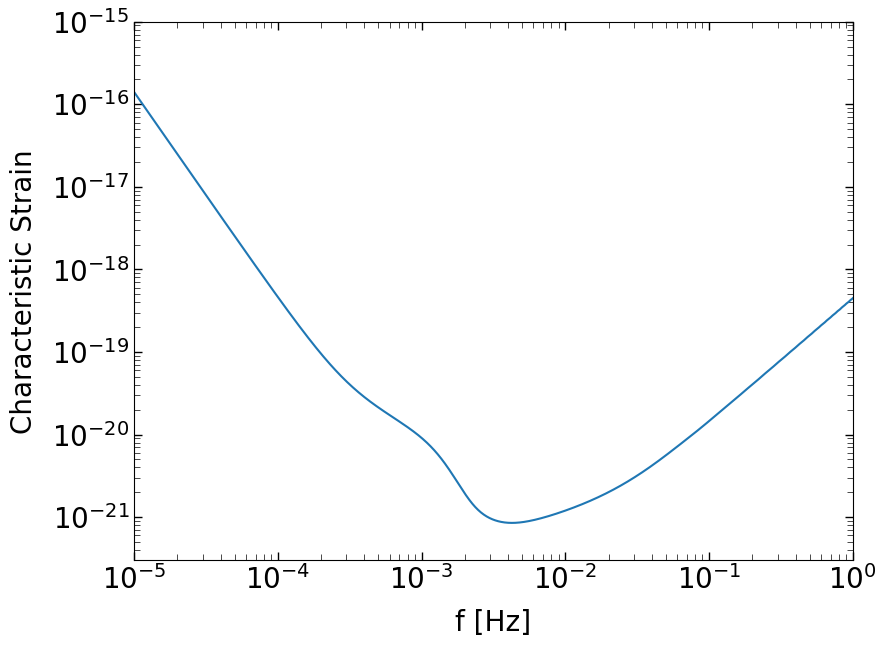

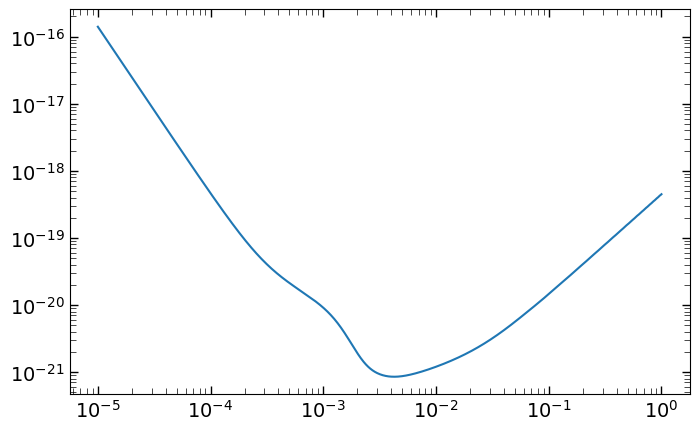

In [3]:
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)
# Plot with the function from LISA module
li.PlotSensitivityCurve(f, Sn)
# Or we can do it ourselves - The same way as in the LISA.py
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, np.sqrt(f*Sn))

In [4]:
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt')
}



det_styles = {
    'LISA':  {'color': 'black', 'ls': '-',   'lw': 2.0},
    'ET-D':  {'color': 'black', 'ls': '--',  'lw': 1.6},
    'ET-B':  {'color': 'black', 'ls': '-.',  'lw': 1.6},
    'ET-C':  {'color': 'black', 'ls': ':',   'lw': 1.6},
    'aLIGO': {'color': 'grey', 'ls': (0, (3, 1, 1, 1, 1, 1)), 'lw': 1.8},  # dash-dot-dot
}

# 1. 170817

In [5]:
# Parameters 
t = np.linspace(-5., 50., 100000) 
r = 40  * 1e6  
theta = np.deg2rad(32)
# Dynamical ejecta
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_s = 1e-3  

start_dyn, end_dyn = -tau_dyn_s * np.log(3)*1e-3, 10*1e-3  

# Wind ejecta
M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_s = 10  

start_wind, end_wind = 10*1e-3, 10 

# GRB
E_grb = 3e46
theta_j = np.deg2rad(5) # jet opening angle

phi_ej = 0
beta = 0.99
end_grb = 2


# Afterglow 
E_aft = 1e52



Dyn - Wind - GRB - Afterglow

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))


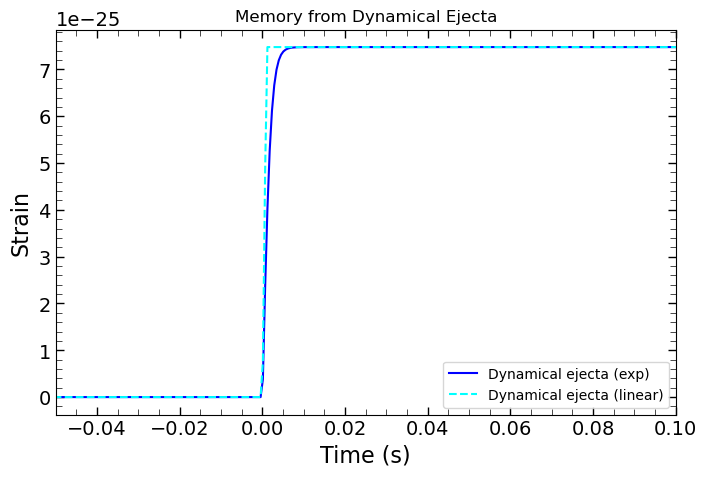

Delta h for dynamical ejecta: 7.48e-25
[1.49544245e-24 1.49544245e-24 1.49544245e-24 1.49544245e-24
 1.49544245e-24 1.49544245e-24 1.49544245e-24 1.49544245e-24
 1.49544245e-24 1.49544245e-24]


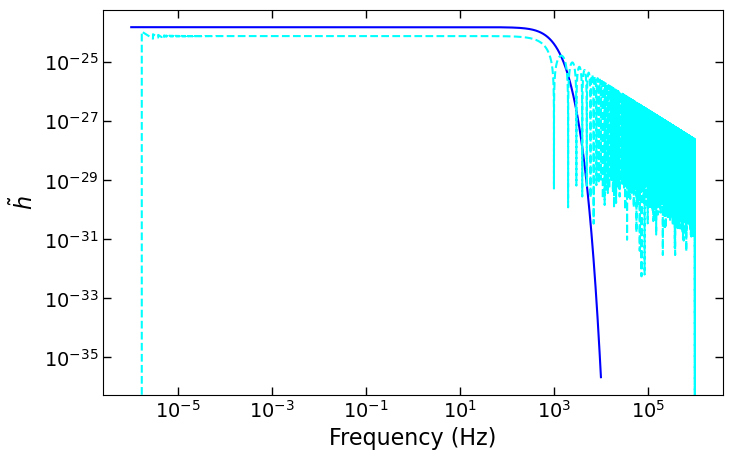

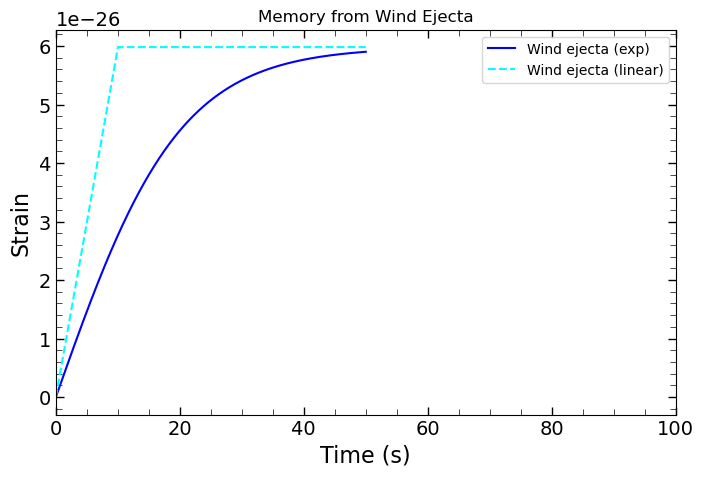

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: overflow encountered in sinh
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in multiply
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in divide
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))


Delta h for GRB: 6.89e-29 Delta h for afterglow: 1.15e-23


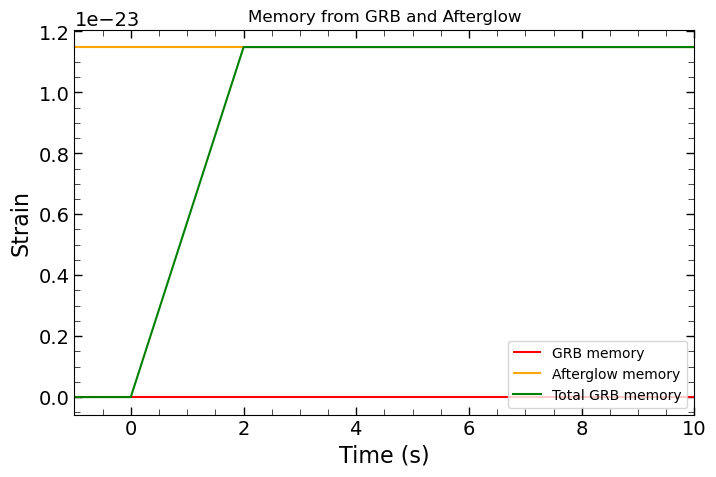

In [6]:
# Dyn
importlib.reload(up)
h_t_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_s, r, start_dyn, model='exponential')
h_t_dyn_lin = up.model_linear(t,up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r), tau_dyn_s, start_dyn)

plt.figure(figsize=(8,5))
plt.plot(t, h_t_dyn, label='Dynamical ejecta (exp)', color='blue')
plt.plot(t, h_t_dyn_lin, label='Dynamical ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-0.05, 0.1)
plt.title('Memory from Dynamical Ejecta')
plt.legend()
plt.show()
delta_h_dyn = up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r)
print(f"Delta h for dynamical ejecta: {delta_h_dyn:.2e}")
f_dyn, fft_dyn = up.fft_exp_model(delta_h_dyn, tau_dyn_s)
print(2* f_dyn[0:10]* fft_dyn[0:10])



f_linear_dyn, fft_dyn_linear = up.memory_fft_formula(up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r), tau_dyn_s, plot=False)

memory_components['dyn'] = {
    't': t,
    'h': h_t_dyn,
    'h_lin': h_t_dyn_lin,
    'f': f_dyn,
    'f_lin': f_linear_dyn,
    'hc': 2* f_dyn * np.abs(fft_dyn),
    'hc_lin':  np.abs(fft_dyn_linear)
}

plt.figure(figsize=(8,5))
plt.loglog(f_dyn, 2*f_dyn*np.abs(fft_dyn), label='Dynamical ejecta (exp)', color='blue')
plt.loglog(f_linear_dyn, np.abs(fft_dyn_linear), label='Dynamical ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$\tilde{h}$')
plt.show()



# Wind
h_t_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_s, r, start_wind, model='exponential')
h_t_wind_lin = up.model_linear(t,up.delta_h_ejecta(M_ej_wind, v_ej_wind, r), tau_wind_s, start_wind)

plt.figure(figsize=(8,5))
plt.plot(t, h_t_wind, label='Wind ejecta (exp)', color='blue')
plt.plot(t, h_t_wind_lin, label='Wind ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-0, 100)
plt.title('Memory from Wind Ejecta')
plt.legend()
plt.show()


f_wind, fft_wind = up.fft_exp_model(h_t_wind[-1], tau_wind_s)

f_linear_wind, fft_wind_linear = up.memory_fft_formula(up.delta_h_ejecta(M_ej_wind, v_ej_wind, r), tau_wind_s, plot=False)

memory_components['wind'] = {
    't': t,
    'h': h_t_wind,
    'h_lin': h_t_wind_lin,
    'f': f_wind,
    'f_lin': f_linear_wind,
    'hc': 2*f_wind*np.abs(fft_wind),
    'hc_lin': np.abs(fft_wind_linear)
}
# GRB
h_in = up.memory_initial_acceleration_GRB(E_grb, theta, phi_ej, r, beta)
# Afterglow
h_aft = ugrb.memory_afterglow(E_aft, theta, phi_ej, r, beta)
h_tot, _ = up.memory_total_waveform(t, h_in, h_aft, end_grb, theta, radius=0)
plt.figure(figsize=(8,5))
plt.hlines(h_in, t[0], t[-1], label='GRB memory', color='red')
plt.hlines(h_aft, t[0], t[-1], label='Afterglow memory', color='orange')
print(f"Delta h for GRB: {h_in:.2e}", f"Delta h for afterglow: {h_aft:.2e}")
plt.plot(t, h_tot, label='Total GRB memory', color='green')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-1, 10)
plt.title('Memory from GRB and Afterglow')
plt.legend()
plt.show()
f, fft_grb_aft = up.new_fft(h_in, h_aft, end_grb, theta, radius=0)

memory_components['grb'] = {
    't': t,
    'h_in': h_in,
    'h_aft': h_aft,
    'h': h_tot,
    'f': f,
    'hc': 2 * f * np.abs(fft_grb_aft)
}



Nonlinear memory

In [7]:
%pip install numpy
%pip install --no-build-isolation NRsur7dq2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


New method used in FT file, import and use it rather than the old one, which is incorrect

In [8]:
import matplotlib
import os
# Récupère le chemin du répertoire de configuration de Matplotlib
config_dir = matplotlib.get_configdir()
print(f"Le répertoire de configuration de Matplotlib est :\n{config_dir}")
# voir les fichiers dans ce répertoire
print(f"Fichiers dans le répertoire de configuration de Matplotlib :\n{os.listdir(config_dir)}")

# Lister tous les styles disponibles pour vérifier que le vôtre est présent
print("Styles disponibles :", plt.style.available)



Le répertoire de configuration de Matplotlib est :
/home/stu_brabant/.config/matplotlib
Fichiers dans le répertoire de configuration de Matplotlib :
['matplotlibrc']
Styles disponibles : ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


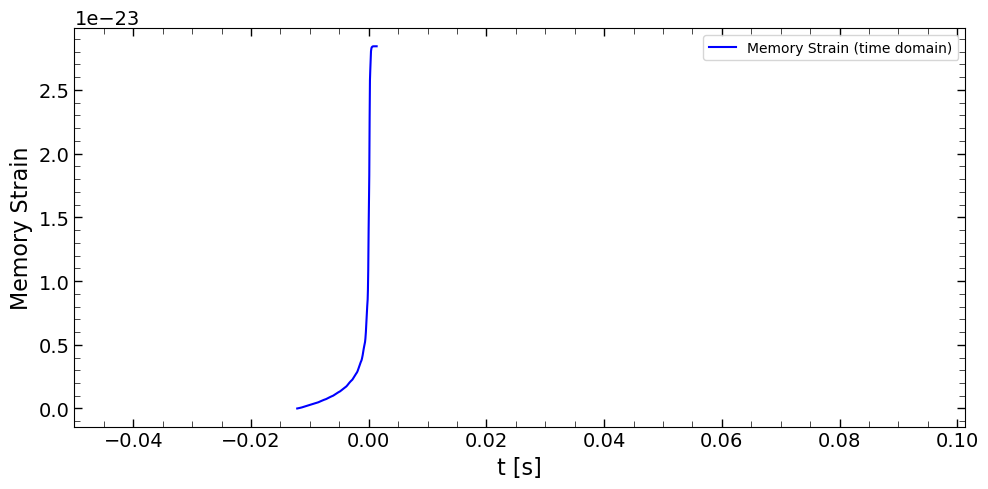

/tmp/ipykernel_539905/3287954505.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/stu_brabant/.conda/envs/memory_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


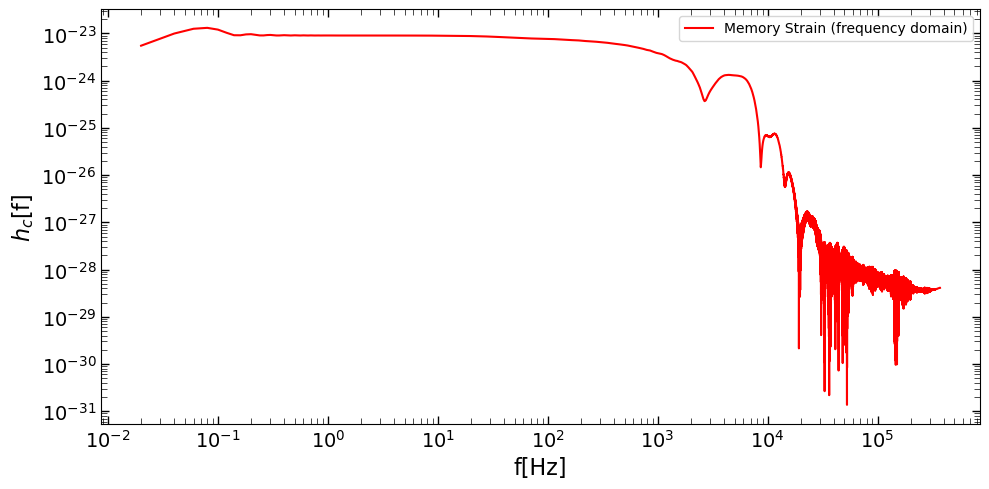

In [9]:
data_import_time = np.loadtxt('GW170817_memory_time_domain.txt')
data_import_freq = np.loadtxt('GW170817_memory_characteristic_strain.txt')
times_mem_170817 = data_import_time[:, 0]
h_mem_170817 = data_import_time[:, 1]
frequencies_ft = data_import_freq[:, 0]
h_mem_ft = data_import_freq[:, 1]

plt.figure(figsize=(10, 5))
plt.plot(times_mem_170817, h_mem_170817, label='Memory Strain (time domain)', color='blue')
plt.xlim(-0.05, times_mem_170817[-1]+ 0.1)
plt.xlabel('t [s]')
plt.ylabel('Memory Strain')
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
plt.loglog(frequencies_ft, h_mem_ft, label='Memory Strain (frequency domain)', color='red')
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.legend()
plt.tight_layout()
plt.show()

memory_components['nonlinear'] ={
        't': times_mem_170817,
        'h': h_mem_170817,
        'f': frequencies_ft,
        'hc': h_mem_ft
}


Kilonova

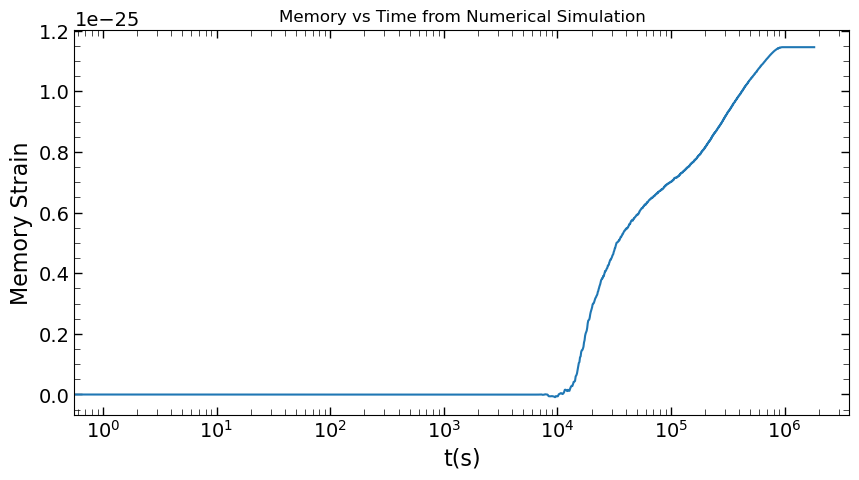

In [10]:
data = np.loadtxt('memory_vs_time_32deg.txt', skiprows=1)
time_data = data[:, 0]
memory_data = data[:, 1]

# Pad the signal from t=0 à t=time_data_seconds[0] par une valeur constante de 0
pad_times = np.linspace(0, time_data[0], len(time_data))  
pad_memory = np.zeros_like(pad_times)

# Concaténer le padding avec les données originales
time_data_seconds_padded = np.concatenate([pad_times, time_data])
memory_data_padded = np.concatenate([pad_memory, memory_data])

# Pad le signal sur 10 s après la fin du signal
pad_times_end = np.linspace(time_data_seconds_padded[-1], time_data_seconds_padded[-1] + 10, len(time_data))  
pad_memory_end = np.full_like(pad_times_end, memory_data_padded[-1])  # Pad avec la dernière valeur du signal
time_data_seconds_padded = np.concatenate([time_data_seconds_padded, pad_times_end])
memory_data_padded = np.concatenate([memory_data_padded, pad_memory_end])

plt.figure(figsize=(10, 5))
plt.plot(time_data_seconds_padded*24*3600, memory_data_padded)
plt.xlabel('t(s)')
plt.xscale('log')
plt.ylabel('Memory Strain')
plt.title('Memory vs Time from Numerical Simulation')
plt.show()


memory_components['kilonova'] = {
        't': time_data_seconds_padded*24*3600,
        'h': memory_data_padded
}


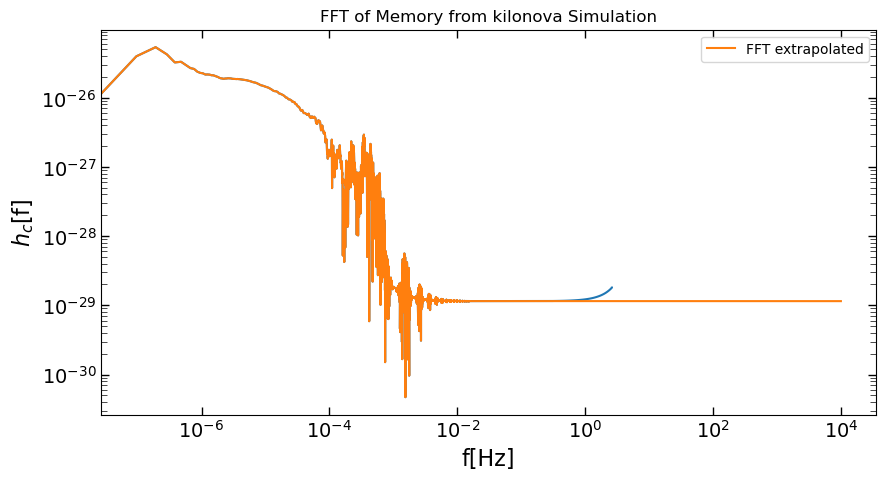

In [11]:
data = np.loadtxt('memory_fft_32deg_interp.txt', skiprows=1)
frequencies = data[:, 0]
h_c = data[:, 1]
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, h_c)
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.title('FFT of Memory from kilonova Simulation')


# cut the frequencies above 1e-1 Hz to avoid the noise from the interpolation
mask = frequencies <= 1e-1
frequencies = frequencies[mask]
h_c = h_c[mask]
# extrapole the fft with constant value up to 1e3 Hz ( = 1/f extrapolation for \tilde h)
frequencies_extrap = np.logspace(np.log10(frequencies[-1]), np.log10(1e4), 100)
h_c_extrap = np.full_like(frequencies_extrap, h_c[-1])
frequencies = np.concatenate([frequencies, frequencies_extrap])
h_c = np.concatenate([h_c, h_c_extrap])

plt.loglog(frequencies, h_c, label='FFT extrapolated')
plt.legend()
plt.show()

memory_components['kilonova']['f'] = frequencies
memory_components['kilonova']['hc'] = h_c

Plot for the frequency domain

key:  dyn
key:  wind
key:  grb
key:  nonlinear
key:  kilonova


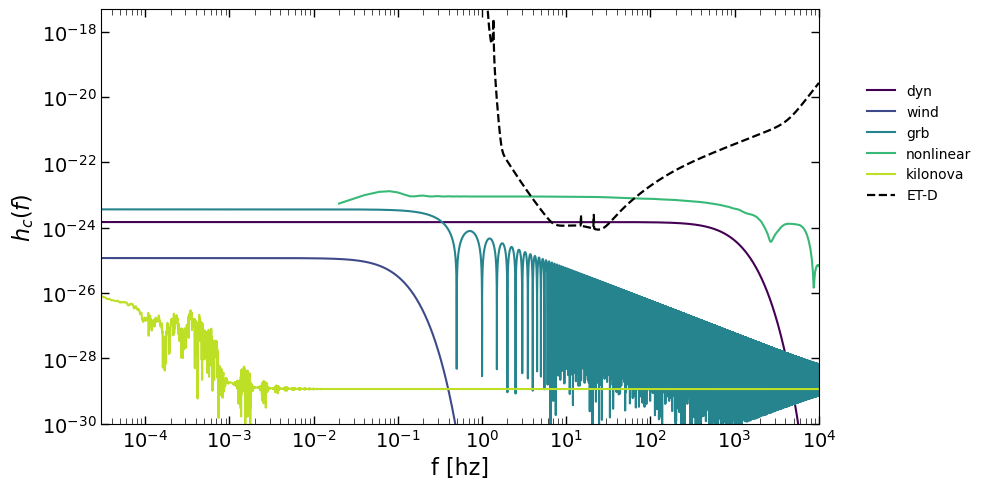

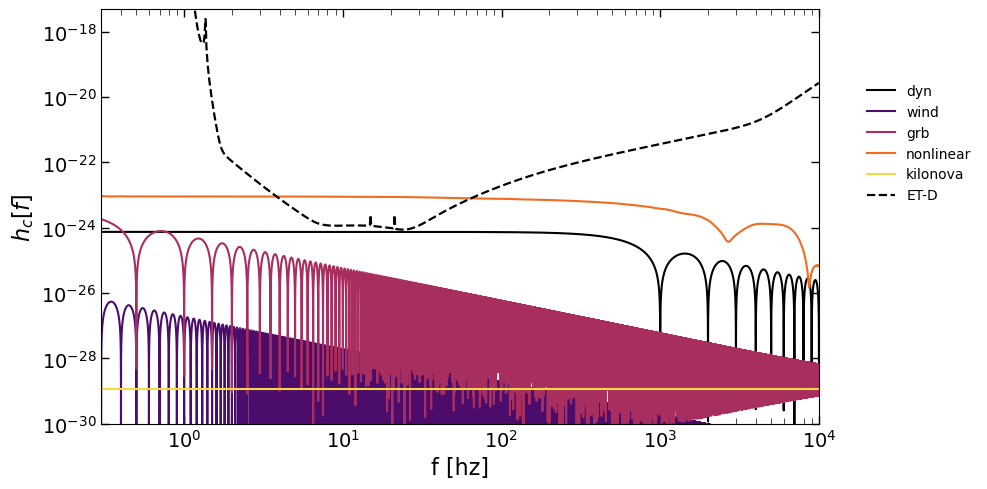

In [12]:
plt.figure(figsize=(10, 5))
cmap = plt.get_cmap('viridis')
# colors based on the number of components of memory_components
colors = [cmap(i) for i in np.linspace(0, 0.9, len(memory_components))]
labels = list(memory_components.keys())

# plot the freq spectra of the memory components
for key in memory_components:
    print('key: ', key)
    f = memory_components[key]['f']
    hc = memory_components[key]['hc']
    plt.plot(f, hc, label=key, color=colors[labels.index(key)])


det_handles = []
# ET configurations
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = plt.loglog(data[:, 0], data[:, 1],
                         color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                         label=det_label)
    det_handles.append(line)

plt.xscale('log')
plt.xlabel('f [hz]')
plt.ylabel(r'$h_c(f)$')
plt.xlim(3e-5, 1e4)
plt.ylim(1e-30, 5e-18)

plt.legend(loc = 'upper left', frameon=False, bbox_to_anchor=(1.05,0.85))
plt.tight_layout()
plt.show()

# Idem mais on remplace les courbes de mémoire par les courbes linéaires
plt.figure(figsize=(10, 5))
# On fait une list des fft linéaires à partir des composants de mémoire pour le dyn et wind, et on garde les courbes de mémoire pour le grb nonlinear, et la kilonova
fft_list_lin = [memory_components['dyn']['hc_lin'], memory_components['wind']['hc_lin'], memory_components['grb']['hc'], memory_components['nonlinear']['hc'],  memory_components['kilonova']['hc']]
f_list_lin = [memory_components['dyn']['f_lin'], memory_components['wind']['f_lin'], memory_components['grb']['f'],memory_components['nonlinear']['f'], memory_components['kilonova']['f']]
cmap = plt.get_cmap('inferno')
colors_l = [cmap(i) for i in np.linspace(0, 0.9, len(memory_components))]

for f, fft, label, color in zip(f_list_lin, fft_list_lin, labels, colors_l):
    plt.plot(f, fft, label=label, color=color, linestyle='-')
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = plt.loglog(data[:, 0], data[:, 1],
                         color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                         label=det_label)
    det_handles.append(line)
plt.xscale('log')
plt.xlabel('f [hz]')
plt.ylabel(r'$h_c[f]$')
plt.xlim(3e-1, 1e4)
plt.ylim(1e-30, 5e-18)
plt.legend(loc = 'upper left', frameon=False, bbox_to_anchor=(1.05,0.85))
plt.tight_layout()
plt.show()


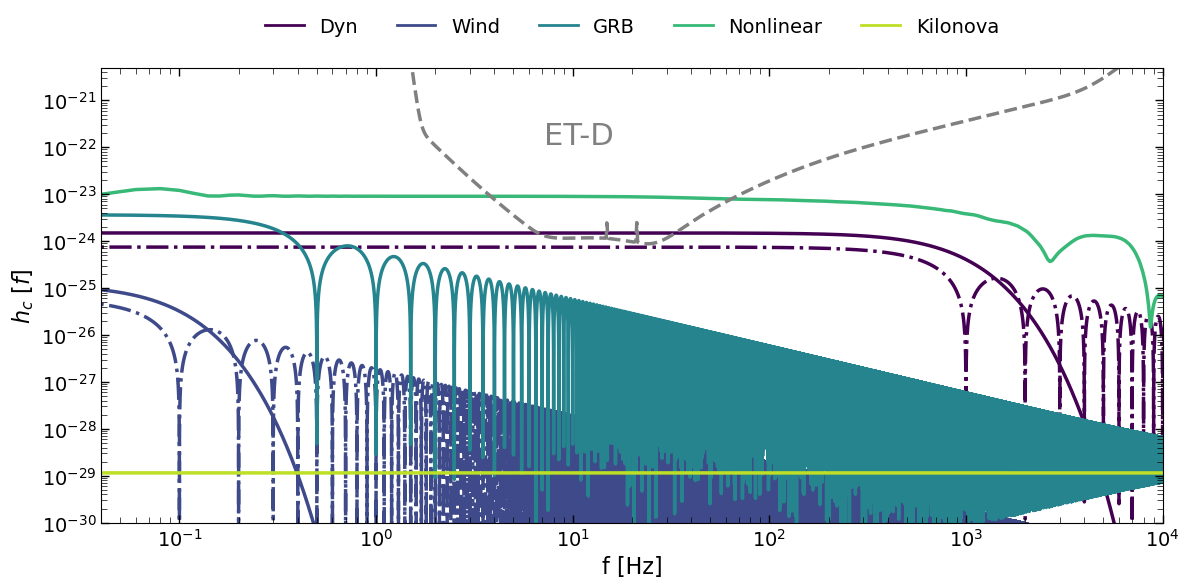

In [13]:
plt.figure(figsize=(12, 6))


cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 0.9, len(memory_components))]
labels = list(memory_components.keys())
#colors = ['royalblue', 'crimson', 'darkorange', 'teal', 'purple']
# Plot des composants de mémoire
for i, key in enumerate(labels):
    color = colors[i]
    
    # Courbe de base (mémoire) - solide
    f = memory_components[key]['f']
    hc = memory_components[key]['hc']
    plt.loglog(f, hc, color=color, linestyle='-', linewidth=2.5, zorder =2)
    
    # Si dyn ou wind, ajouter aussi la courbe linéaire - tirets
    if key in ['dyn', 'wind']:
        f_lin = memory_components[key]['f_lin']
        hc_lin = memory_components[key]['hc_lin']
        plt.loglog(f_lin, hc_lin, color=color, linestyle='-.', linewidth=2.5, zorder = 1)

# Plot des sensibilités des détecteurs
det_handles = []
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = plt.loglog(data[:, 0], data[:, 1],
                        color='grey', linestyle=s['ls'], linewidth=2.5,
                        label=det_label)
    # capital letter for the detector label in the legend
    det_label = det_label.upper()
    plt.text(0.45, 0.85, det_label, transform=plt.gca().transAxes, fontsize=22, color='grey', ha='center', va='center', rotation=0 )

# Créer les handles pour la légende
from matplotlib.lines import Line2D

handles = []

for i, key in enumerate(labels):
    # majuscule pour la légende
    label = key.capitalize()
    if key == 'grb':
        label = key.upper()  # GRB en majuscules
    handles.append(Line2D([0], [0], color=colors[i], linestyle='-', linewidth=2, label=label))



plt.xlabel('f [Hz]')
plt.ylabel(r'$h_c~[f]$')
plt.xlim(4e-2, 1e4)
plt.ylim(1e-30, 5e-21)

plt.legend(handles=handles, loc='upper center', frameon=False, 
           bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=14)
# makes to ticks in front of the plot (zorder higher than the lines)
ax = plt.gca()

ax.set_axisbelow(False)


plt.tight_layout()
plt.show()

Test with seaborn 

processing component: dyn
processing component: wind
processing component: grb
processing component: nonlinear
processing component: kilonova
DataFrame créé avec 227772 points après sous-échantillonnage.
ok


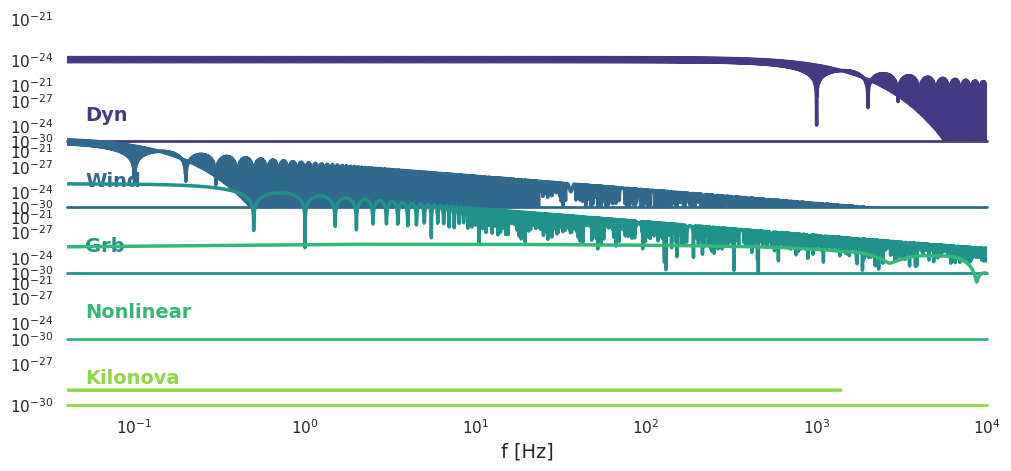

In [14]:
import pandas as pd
import seaborn as sns
# --- 1. Préparation des données avec SOUS-ÉCHANTILLONNAGE ---
plot_data = []
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# PRENEZ 1 POINT TOUS LES 'step' POINTS. Augmentez si c'est encore trop lent.
step = 100 

for key, component in memory_components.items():
    print(f'processing component: {key}')
    # Applique le pas (step) pour réduire le nombre de points
    f_sampled = component['f'][::step]
    hc_sampled = component['hc'][::step]
    for f, hc in zip(f_sampled, hc_sampled):
        plot_data.append({'f': f, 'hc': hc, 'component': key.capitalize(), 'type': 'Memory'})
    
    if 'f_lin' in component:
        f_lin_sampled = component['f_lin'][::step]
        hc_lin_sampled = component['hc_lin'][::step]
        for f, hc in zip(f_lin_sampled, hc_lin_sampled):
            plot_data.append({'f': f, 'hc': hc, 'component': key.capitalize(), 'type': 'Linear'})

df_plot = pd.DataFrame(plot_data)

print(f"DataFrame créé avec {len(df_plot)} points après sous-échantillonnage.")

# --- 2. Création du Ridge Plot avec FacetGrid ---
# Initialise le FacetGrid
g = sns.FacetGrid(df_plot, row="component", hue="component", aspect=10, height=1,
                  palette='viridis', row_order=[k.capitalize() for k in memory_components.keys()])
print('ok')
# Trace les courbes de densité (ici, nos lignes hc vs f)
g.map(sns.lineplot, "f", "hc", alpha=1, linewidth=2.5)

# Ajoute une ligne horizontale pour chaque graphique pour marquer la base
g.map(plt.axhline, y=1e-30, lw=2, clip_on=False)

# Fonction pour ajouter le label de chaque composant
def label(x, color, label):
    ax = plt.gca()
    ax.text(0.02, 0.2, label, fontweight="bold", color=color, 
            ha="left", va="center", transform=ax.transAxes, fontsize=14)

g.map(label, "f")

# Ajuste les sous-graphiques pour qu'ils se chevauchent
g.fig.subplots_adjust(hspace=-0.5)

# Supprime les titres et les axes y qui ne sont pas nécessaires
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Configure l'axe X commun
g.set(xscale='log', yscale='log')
g.set_xlabels("f [Hz]", fontsize=14)
g.set(xlim=(4e-2, 1e4), ylim=(1e-30, 5e-21))

plt.show()

In [15]:
import pandas as pd

# Listes pour construire les DataFrames
rows_full = []
rows_linear = []

# Traitement de 'dyn' et 'wind'
for component_name in ['dyn', 'wind']:
    comp_data = memory_components[component_name]
    
    # Modèle complet ('Memory')
    rows_full.append(pd.DataFrame({
        'f': comp_data['f'],
        'hc': comp_data['hc'],
        'component': component_name
    }))
    
    # Modèle linéaire
    rows_linear.append(pd.DataFrame({
        'f': comp_data['f_lin'],
        'hc': comp_data['hc_lin'],
        'component': component_name
    }))

# Traitement de 'grb', 'nonlinear', 'kilonova'
for component_name in ['grb', 'nonlinear', 'kilonova']:
    comp_data = memory_components[component_name]
    
    # Ces composants n'ont qu'un seul modèle, qui va dans le DF "full"
    rows_full.append(pd.DataFrame({
        'f': comp_data['f'],
        'hc': comp_data['hc'],
        'component': component_name
    }))

# Création des deux DataFrames
df_full_models = pd.concat(rows_full, ignore_index=True)
df_linear_models = pd.concat(rows_linear, ignore_index=True)

# Pour la visualisation, nous créons un DataFrame unifié avec une colonne 'type'
df_full_models['type'] = 'Full Model'
df_linear_models['type'] = 'Linear Model'

# df_plot_corrected est le DataFrame final à utiliser pour les graphiques
df_plot_corrected = pd.concat([df_full_models, df_linear_models], ignore_index=True)


print("DataFrames créés avec succès.")
print("\n--- Modèles Complets ('Full Model') ---")
print("Composants:", df_full_models['component'].unique())

print("\n--- Modèles Linéaires ('Linear Model') ---")
print("Composants:", df_linear_models['component'].unique())

print("\n--- DataFrame combiné pour le plot ---")
print(df_plot_corrected.groupby(['component', 'type']).size())

DataFrames créés avec succès.

--- Modèles Complets ('Full Model') ---
Composants: <StringArray>
['dyn', 'wind', 'grb', 'nonlinear', 'kilonova']
Length: 5, dtype: str

--- Modèles Linéaires ('Linear Model') ---
Composants: <StringArray>
['dyn', 'wind']
Length: 2, dtype: str

--- DataFrame combiné pour le plot ---
component  type        
dyn        Full Model        100000
           Linear Model     1000000
grb        Full Model       1000000
kilonova   Full Model       1047818
nonlinear  Full Model      18529220
wind       Full Model        100000
           Linear Model     1000000
dtype: int64


In [16]:
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

# --- 1. Configuration ---
f_min_safe = max(df_plot_corrected[df_plot_corrected['f'] > 0]['f'].min(), 1e-5)
f_max_safe = df_plot_corrected['f'].max()
f_common = np.logspace(np.log10(f_min_safe), np.log10(f_max_safe), 2000)

# --- 2. Calcul de la somme des "Full Models" ---
total_sum_full = np.zeros_like(f_common)
for component in df_full_models['component'].unique():
    subset = df_full_models[df_full_models['component'] == component]
    subset_safe = subset[subset['f'] > 0]
    if not subset_safe.empty:
        interp_func = interp1d(subset_safe['f'].values, subset_safe['hc'].values, kind='linear', bounds_error=False, fill_value=(subset_safe['hc'].values[0], subset_safe['hc'].values[-1]))
        hc_interp = interp_func(f_common)
        total_sum_full += np.nan_to_num(hc_interp, nan=0.0, posinf=0.0, neginf=0.0)

# --- 3. Calcul de la somme des "Linear Models" ---
total_sum_linear = np.zeros_like(f_common)
# itère sur dyn et wind uniquement, car ce sont les seuls à avoir un modèle linéaire + kn + grb + nonlinéaire
for component in ['dyn', 'wind']:
    subset = df_linear_models[df_linear_models['component'] == component]
    subset_safe = subset[subset['f'] > 0]
    if not subset_safe.empty:
        interp_func = interp1d(subset_safe['f'].values, subset_safe['hc'].values, kind='linear', bounds_error=False, fill_value=(subset_safe['hc'].values[0], subset_safe['hc'].values[-1]))
        hc_interp = interp_func(f_common)
        total_sum_linear += np.nan_to_num(hc_interp, nan=0.0, posinf=0.0, neginf=0.0)
# add the grb, nonlinéaire et kn à la somme linéaire pour faire une comparaison plus juste
for component in ['grb', 'nonlinear', 'kilonova']:
    subset = df_full_models[df_full_models['component'] == component]
    subset_safe = subset[subset['f'] > 0]
    if not subset_safe.empty:
        interp_func = interp1d(subset_safe['f'].values, subset_safe['hc'].values, kind='linear', bounds_error=False, fill_value=(subset_safe['hc'].values[0], subset_safe['hc'].values[-1]))
        hc_interp = interp_func(f_common)
        total_sum_linear += np.nan_to_num(hc_interp, nan=0.0, posinf=0.0, neginf=0.0)

# --- 4. Préparation des données de la somme pour le DataFrame ---
df_sum_full_rows = [{'f': f, 'hc': hc, 'component': 'Total Sum', 'type': 'Full Model'} for f, hc in zip(f_common, total_sum_full)]
df_sum_linear_rows = [{'f': f, 'hc': hc, 'component': 'Total Sum', 'type': 'Linear Model'} for f, hc in zip(f_common, total_sum_linear)]

df_sum = pd.DataFrame(df_sum_full_rows + df_sum_linear_rows)

# Ajouter les sommes au DataFrame de plotting
df_plot_final = pd.concat([df_plot_corrected, df_sum], ignore_index=True)

print("Calcul des deux sommes terminé.")
print("Le DataFrame 'df_plot_final' est prêt pour la visualisation.")
print("Types pour 'Total Sum':", df_plot_final[df_plot_final['component'] == 'Total Sum']['type'].unique())

Calcul des deux sommes terminé.
Le DataFrame 'df_plot_final' est prêt pour la visualisation.
Types pour 'Total Sum': <StringArray>
['Full Model', 'Linear Model']
Length: 2, dtype: str


Fichier de sensibilité ET-D chargé.
Plotting component: dyn in subplot 1/6
Plotting component: wind in subplot 2/6
Plotting component: grb in subplot 3/6
Plotting component: nonlinear in subplot 4/6
Plotting component: kilonova in subplot 5/6
Plotting component: Total Sum in subplot 6/6


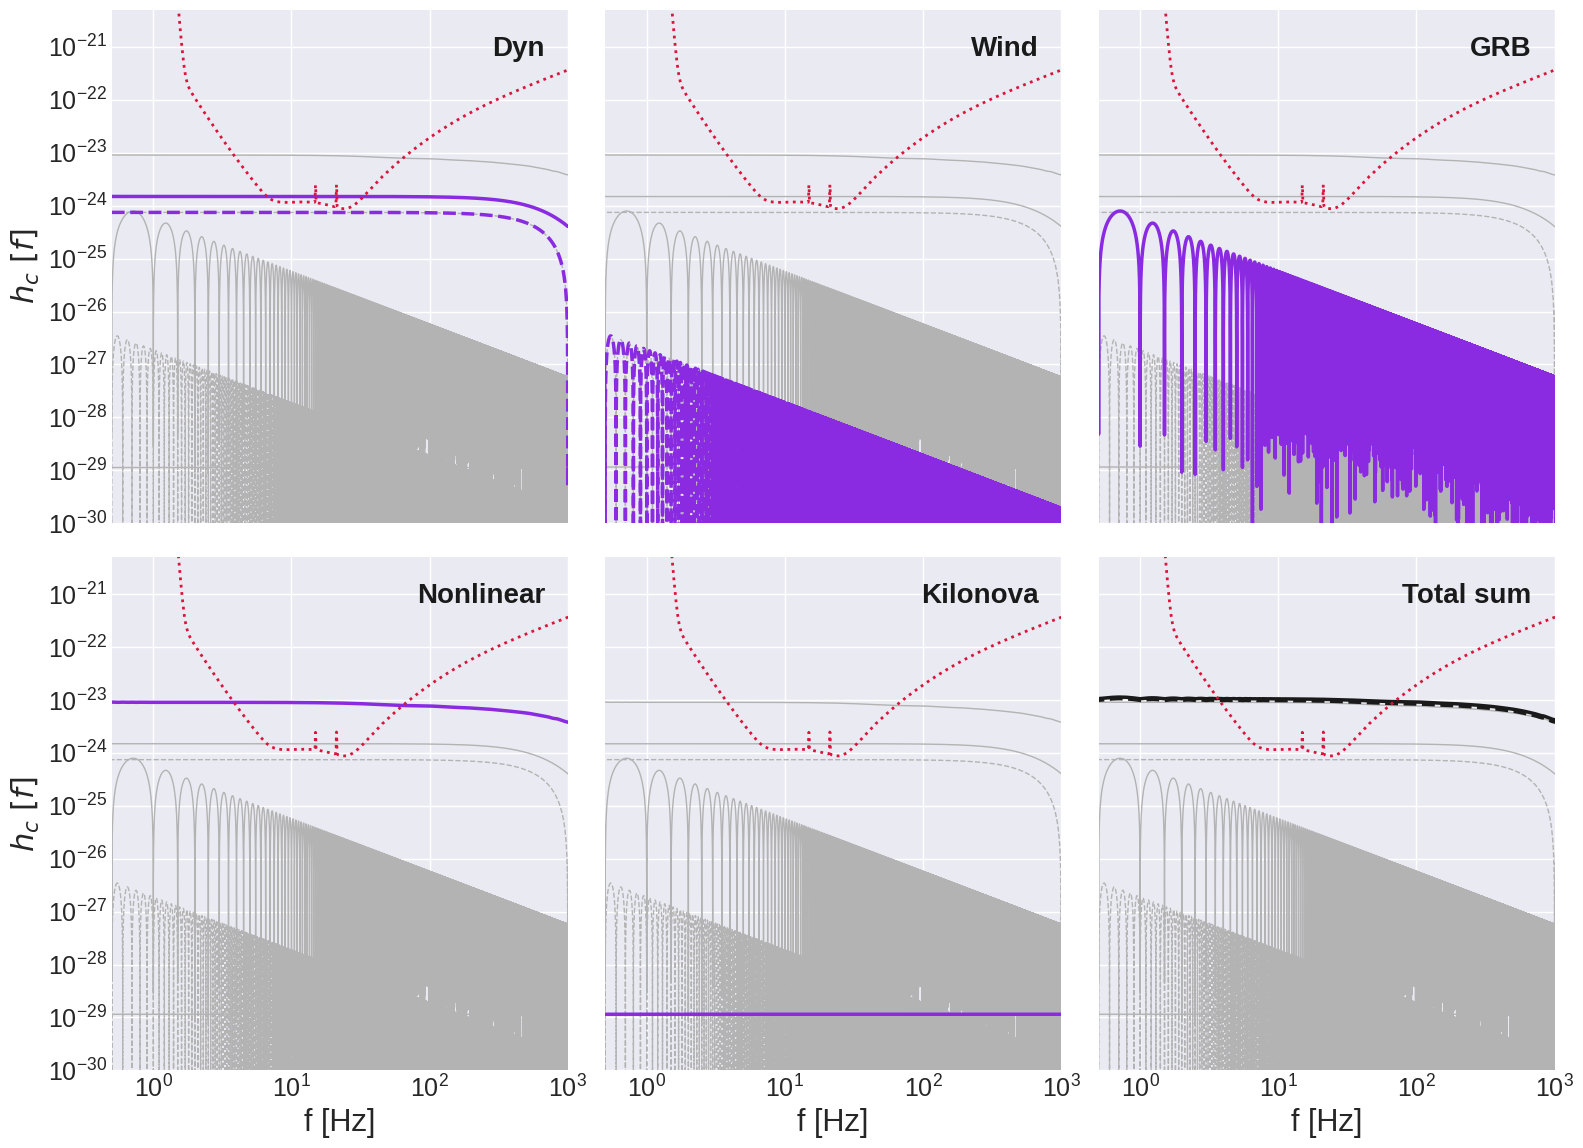

In [18]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import seaborn as sns # Importé pour la palette

# --- 1. Configuration de la visualisation (tout est ici) ---
plt.style.use('seaborn-v0_8-darkgrid')

# Charger les données de sensibilité d'ET-D
try:
    et_d_sensi = np.loadtxt('ET_D_sensi.txt')
    print("Fichier de sensibilité ET-D chargé.")
except FileNotFoundError:
    print("Attention : Fichier 'All_memory/ET_D_sensi.txt' non trouvé.")
    et_d_sensi = None

# Définition de la grille de graphiques
all_components_plot = list(df_plot_corrected['component'].unique()) + ['Total Sum']
n_cols = 3
n_rows = (len(all_components_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,12), sharex=True, sharey=True)
axes_flat = axes.flatten()

# --- DÉFINITION DE LA PALETTE BLEUE (LA PARTIE IMPORTANTE) ---
components_unique = df_plot_corrected['component'].unique()
color = '#8A2BE2'  # Couleur de base pour les composants
colors = {comp: color for comp in (components_unique)}

colors['Total Sum'] = 'k' # Somme en noir 

styles = {'Full Model': '-', 'Linear Model': '--'}

# --- 2. Boucle de traçage ---
for i, component in enumerate(all_components_plot):
    ax = axes_flat[i]
    print(f"Plotting component: {component} in subplot {i+1}/{len(all_components_plot)}")
    # A. Arrière-plan
    background_data = df_plot_final[df_plot_final['component'] != 'Total Sum']
    for bg_comp in background_data['component'].unique():
        for bg_type in ['Full Model', 'Linear Model']:
            plot_data = background_data[(background_data['component'] == bg_comp) & (background_data['type'] == bg_type)]
            if not plot_data.empty:
                ax.plot(plot_data['f'], plot_data['hc'], color=".7", ls=styles[bg_type], lw=1, zorder=1)

    # B. Premier plan
    main_data = df_plot_final[df_plot_final['component'] == component]
    for sig_type in main_data['type'].unique():
        plot_data = main_data[main_data['type'] == sig_type]
        if not plot_data.empty:
            # Utilise le dictionnaire 'colors' défini juste au-dessus
            ax.plot(plot_data['f'], plot_data['hc'], color=colors[component], ls=styles[sig_type], lw=2.5, zorder=5)
            
    # C. Courbe de sensibilité
    if et_d_sensi is not None:
        ax.plot(et_d_sensi[:, 0], et_d_sensi[:, 1], color='crimson', ls=':', lw=2, zorder=10)

    # D. Annotation et mise en forme
    # text en maj pour le label du composant sauf pour total sum
    component= component.upper() if component == 'grb' else component.capitalize()
    ax.text(0.95, 0.95, component, transform=ax.transAxes, fontweight='bold', 
            fontsize=20, ha='right', va='top', color='k')
    ax.set(xscale='log', yscale='log', xlim=(5e-1, 1e3), ylim=(1e-30, 5e-21))
    # xlabel seulement pour la dernière ligne de sous-graphiques
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('f [Hz]', fontsize=22)
    else:
        ax.set_xlabel('')
    # ylabel seulement pour la première colonne de sous-graphiques
    if i % n_cols == 0:
        ax.set_ylabel(r'$h_c~[f]$', fontsize=22)
    else:
        ax.set_ylabel('')

# Cacher les axes non utilisés
for j in range(len(all_components_plot), len(axes_flat)):
    axes_flat[j].set_visible(False)
# augmenter la taille des ticks
for ax in axes_flat:
    ax.tick_params(axis='both', which='major', labelsize=18)

# --- 3. Légende et titre ---
legend_handles = [
    mlines.Line2D([], [], color='gray', linestyle='-', lw=2, label='Full Model'),
    mlines.Line2D([], [], color='gray', linestyle='--', lw=2, label='Linear Model'),
]
if et_d_sensi is not None:
    legend_handles.append(mlines.Line2D([], [], color='crimson', ls=':', lw=2, label='ET-D'))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Plot of the total memory in the time domain

Test with all

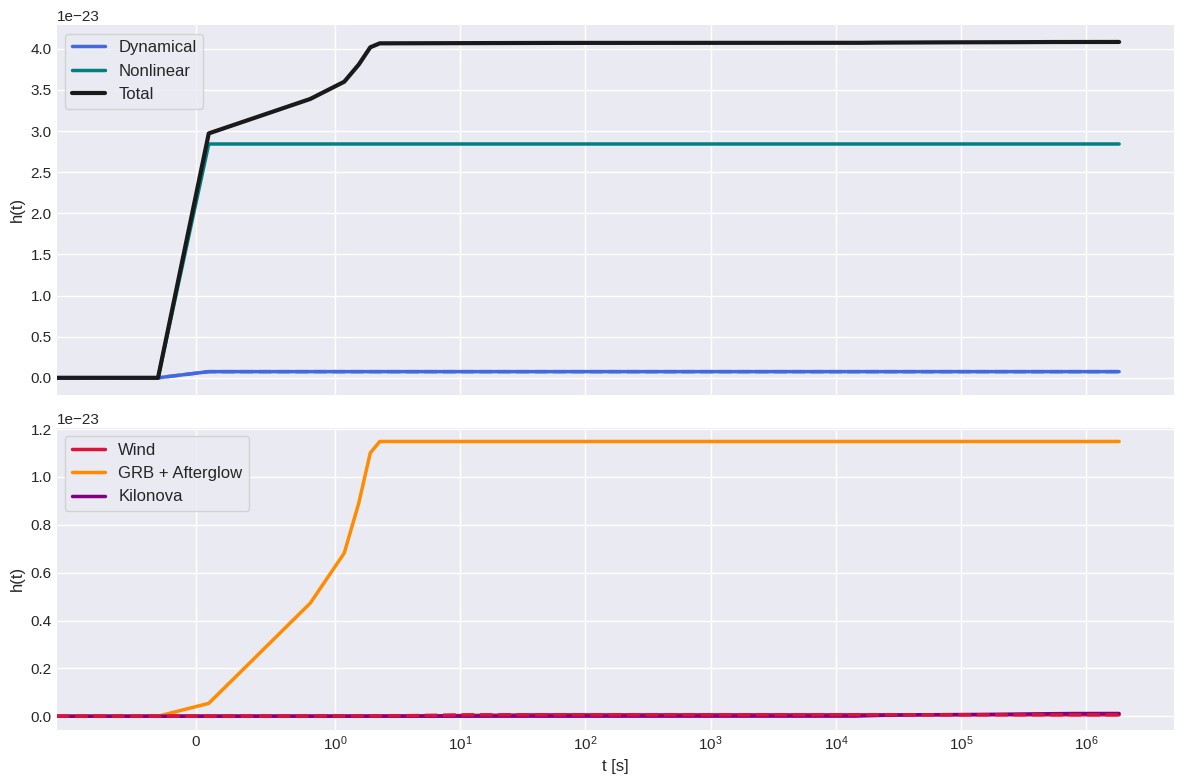

In [33]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration
labels_map = {
    'dyn': 'Dynamical',
    'wind': 'Wind',
    'grb': 'GRB + Afterglow',
    'nonlinear': 'Nonlinear',
    'kilonova': 'Kilonova'
}
colors = {
    'dyn': 'royalblue',
    'wind': 'crimson',
    'grb': 'darkorange',
    'nonlinear': 'teal',
    'kilonova': 'purple'
}

# Grille globale (pour total + panneau "original")
t_min_global = -1
t_max_global = max(memory_components[k]['t'][-1] for k in memory_components.keys())
N_points_global = int(5e6)   # plus léger que 5e6, ajuste si besoin
t_common = np.linspace(t_min_global, t_max_global, N_points_global)

# Grille locale fine pour le zoom dyn/nonlinear
t_zoom_min, t_zoom_max = -10, 5
N_points_zoom = int(5e5)
t_zoom = np.linspace(t_zoom_min, t_zoom_max, N_points_zoom)

def interp_on_grid(t_src, h_src, t_grid):
    f = interp1d(t_src, h_src, kind='linear', bounds_error=False, fill_value=(h_src[0], h_src[-1]))
    return f(t_grid)

# Interpolations globales (modèles exponentiels)
h_global = {}
for key in ['dyn', 'wind', 'grb', 'nonlinear', 'kilonova']:
    h_global[key] = interp_on_grid(memory_components[key]['t'], memory_components[key]['h'], t_common)

# Interpolations linéaires pour dyn/wind (si disponibles)
h_dyn_lin_global = interp_on_grid(memory_components['dyn']['t'], memory_components['dyn']['h_lin'], t_common)
h_wind_lin_global = interp_on_grid(memory_components['wind']['t'], memory_components['wind']['h_lin'], t_common)

# Somme totale (comme ton original: composantes "h")
h_total = h_global['dyn'] + h_global['wind'] + h_global['grb'] + h_global['nonlinear'] + h_global['kilonova']

# Interpolations zoom pour panneau 2
h_dyn_zoom = interp_on_grid(memory_components['dyn']['t'], memory_components['dyn']['h'], t_zoom)
h_dyn_lin_zoom = interp_on_grid(memory_components['dyn']['t'], memory_components['dyn']['h_lin'], t_zoom)
h_nl_zoom = interp_on_grid(memory_components['nonlinear']['t'], memory_components['nonlinear']['h'], t_zoom)

# --- Plot: 2 subplots seulement
fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.8]}
)

ax0, ax1 = axes

# ---------------------------
# (1) Total + toutes composantes + linéaires dyn/wind
# ---------------------------
for key in ['dyn' ,'nonlinear']:
    ax0.plot(t_common, h_global[key], lw=2.5, color=colors[key], label=labels_map[key])

ax0.plot(t_common, h_dyn_lin_global, lw=2.5, ls='--', color=colors['dyn'], alpha=0.9)
#ax0.plot(t_common, h_wind_lin_global, lw=2.5, ls='--', color=colors['wind'], alpha=0.9)
ax0.plot(t_common, h_total, lw=3, color='k', label='Total')

ax0.set_ylabel('h(t)')

ax0.legend(loc='upper left', frameon=True, fontsize=12, ncol=1)

# ---------------------------
# (2) Wind + GRB + Kilonova + Dyn (+ linéaires associés)
# ---------------------------
for key in [ 'wind', 'grb', 'kilonova']:
    ax1.plot(t_common, h_global[key], lw=2.5, color=colors[key], label=labels_map[key])

#ax1.plot(t_common, h_dyn_lin_global, lw=2.5, ls='--', color=colors['dyn'], alpha=0.95, label='Dynamical ejecta (linear)')
ax1.plot(t_common, h_wind_lin_global, lw=2.5, ls='--', color=colors['wind'], alpha=0.95)

ax1.set_ylabel('h(t)')
ax1.set_xlabel('t [s]')

ax1.legend(loc='upper left', frameon=True, fontsize=12, ncol=1)

# Axe partagé
for ax in axes:
    ax.set_xscale('symlog', linthresh=1)

axes[-1].set_xlim(-1, 5e6)

plt.tight_layout()
plt.show()

Linear scale for the time axis

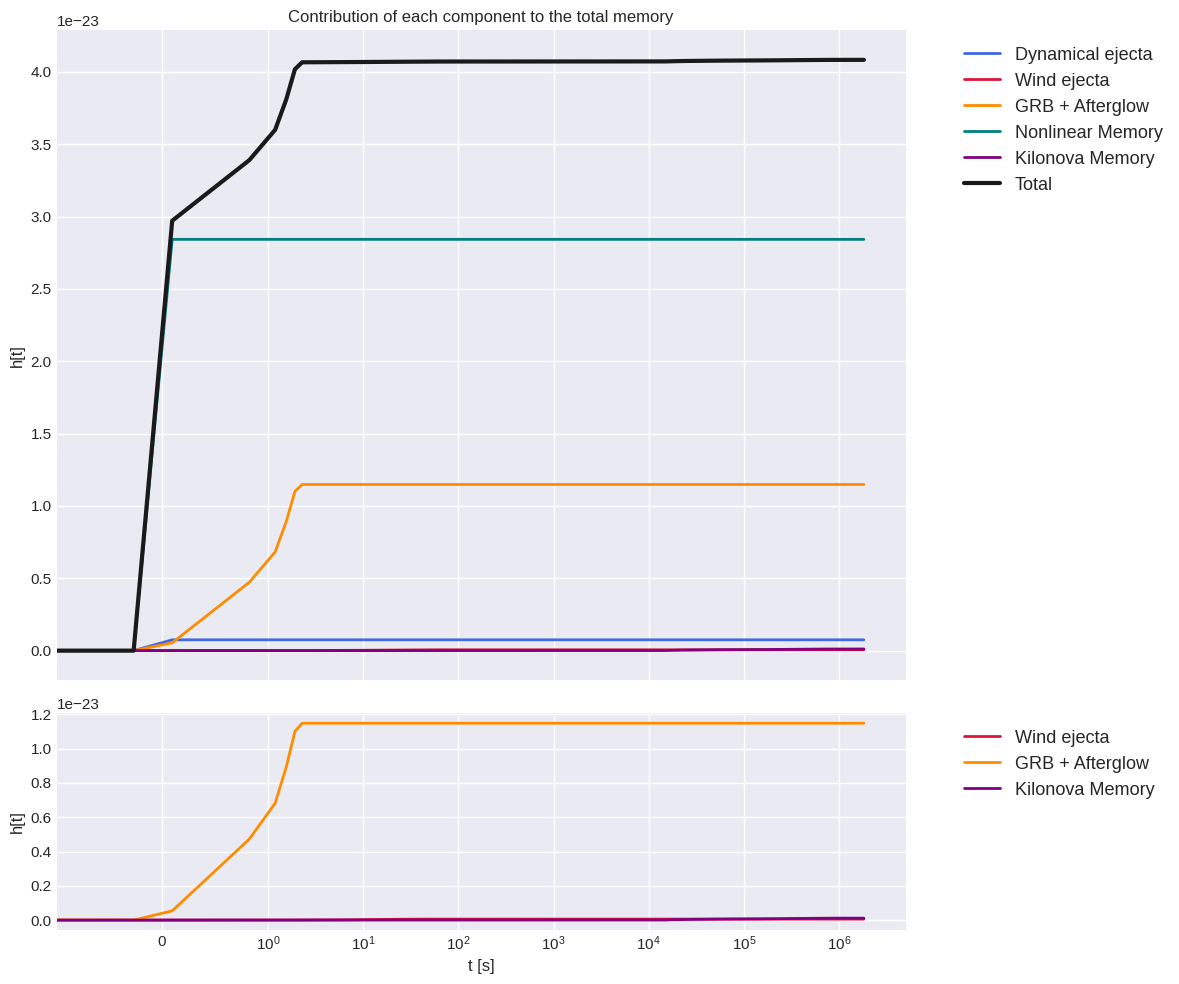

In [34]:
from scipy.interpolate import interp1d

labels = ['Dynamical ejecta ', 'Wind ejecta', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('viridis')
colors = ['royalblue', 'crimson', 'darkorange', 'teal', 'purple']
t_list = [memory_components[key]['t'] for key in memory_components]
h_list = [memory_components[key]['h'] for key in memory_components]

# Grille linéaire en temps, commence à t = -1 s
t_min = -1
t_max = max([t[-1] for t in t_list])
N_points = int(5e6)
t_common = np.linspace(t_min, t_max, N_points)

# Interpolation sur la grille linéaire
h_interp_list = []
for t, h in zip(t_list, h_list):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset (échelle log sur l'axe x)
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels, colors):
    ax_main.plot(t_common, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('symlog', linthresh=1)
ax_main.set_xlim(-1, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common, h_interp_list[i], label=labels[i], color=colors[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('symlog', linthresh=1)
ax_inset.set_xlim(-1, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()



In [35]:
h_lin_dyn = memory_components['dyn']['h_lin']
h_lin_wind = memory_components['wind']['h_lin']
h_list_lin = [h_lin_dyn, h_lin_wind, memory_components['grb']['h'], memory_components['nonlinear']['h'], memory_components['kilonova']['h']]

labels_lin = ['Dynamical ejecta (uniform) ', 'Wind ejecta (uniform)', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('inferno')
colors_lin = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels_lin))]


# Grille linéaire en temps, commence à t = -1 s
t_min = -1
t_max = max([t[-1] for t in t_list])
N_points = int(5e6)
t_common = np.linspace(t_min, t_max, N_points)

# Interpolation sur la grille linéaire
h_interp_list = []

for t, h in zip(t_list, h_list_lin):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)


# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset (échelle log sur l'axe x)
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels_lin, colors_lin):
    ax_main.plot(t_common, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('symlog', linthresh=1)
ax_main.set_xlim(-1, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common, h_interp_list[i], label=labels_lin[i], color=colors_lin[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('symlog', linthresh=1)
ax_inset.set_xlim(-1, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()



KeyboardInterrupt: 

Log scale for the time axis

1.349585e-06


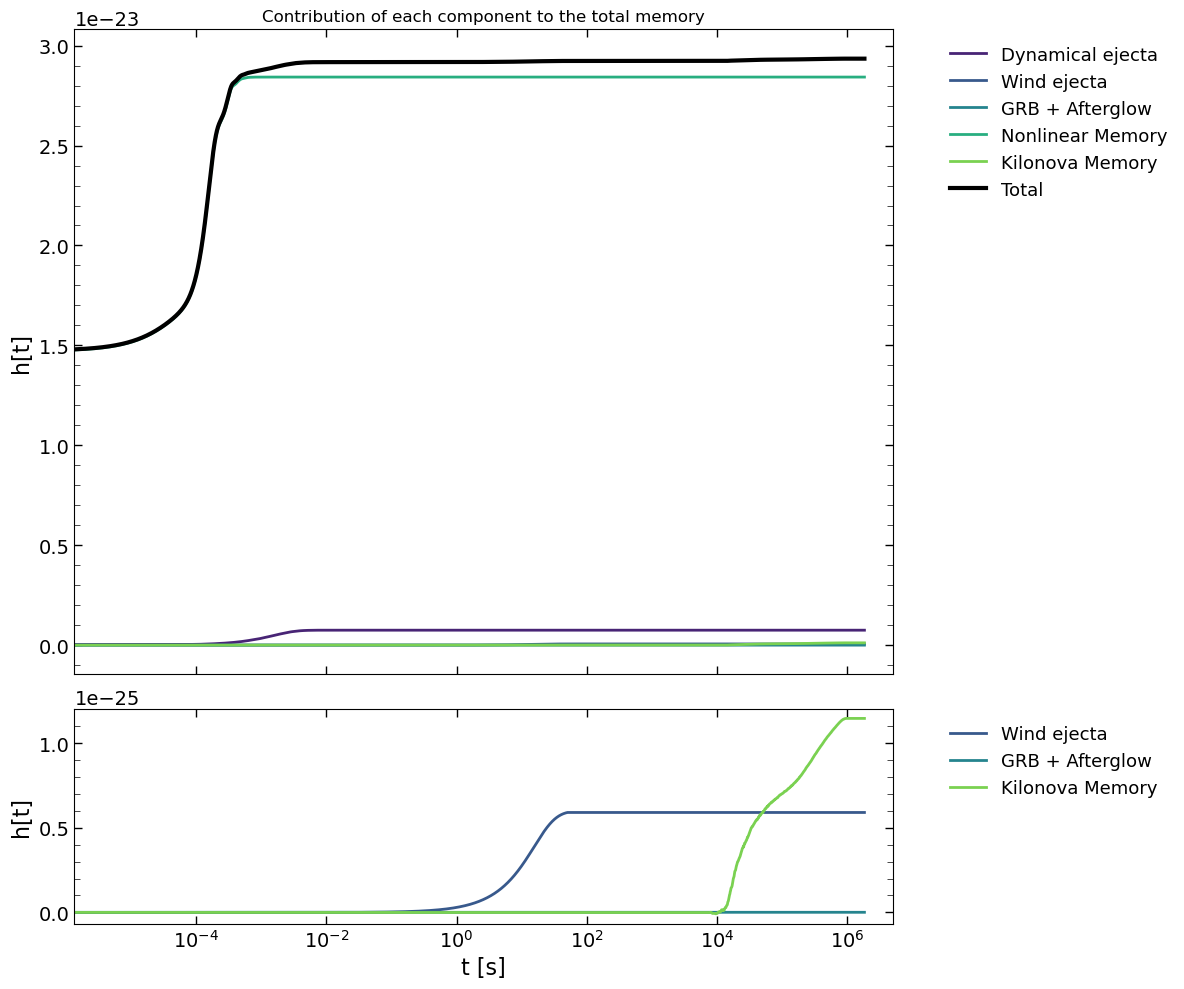

Fréquence de Nyquist estimée : 6.63e+10 Hz


In [ ]:
# Log space grid in time for better visualization of the long-term behavior

labels = ['Dynamical ejecta ', 'Wind ejecta', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels))]
t_list = [memory_components[key]['t'] for key in memory_components]
h_list = [memory_components[key]['h'] for key in memory_components]
# Grille logarithmique en temps
t_min_candidates = [t[0] for t in t_list if t[0] > 0]
if len(t_min_candidates) == 0:
    # Si tous les t[0] sont <= 0, prends le plus petit t positif dans tous les tableaux
    t_min = min([np.min(t[t > 0]) for t in t_list if np.any(t > 0)])
    print(t_min)
else:
    t_min = min(t_min_candidates)
t_max = max([t[-1] for t in t_list])
N_points = int(5e6)  

t_common_log = np.logspace(np.log10(t_min), np.log10(t_max), N_points)

# Interpolation sur la grille log
h_interp_list = []
for t, h in zip(t_list, h_list):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common_log)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels, colors):
    ax_main.plot(t_common_log, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common_log, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('log')
ax_main.set_xlim(t_min, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common_log, h_interp_list[i], label=labels[i], color=colors[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('log')
ax_inset.set_xlim(t_min, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Vérification de la fréquence de Nyquist
dt_min = np.min(np.diff(t_common_log))
print(f"Fréquence de Nyquist estimée : {0.5/dt_min:.2e} Hz")


/tmp/ipykernel_3218794/3027581151.py:39: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(-1, 5e6)
/tmp/ipykernel_3218794/3027581151.py:48: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_inset.set_xlim(-1, 5e6)


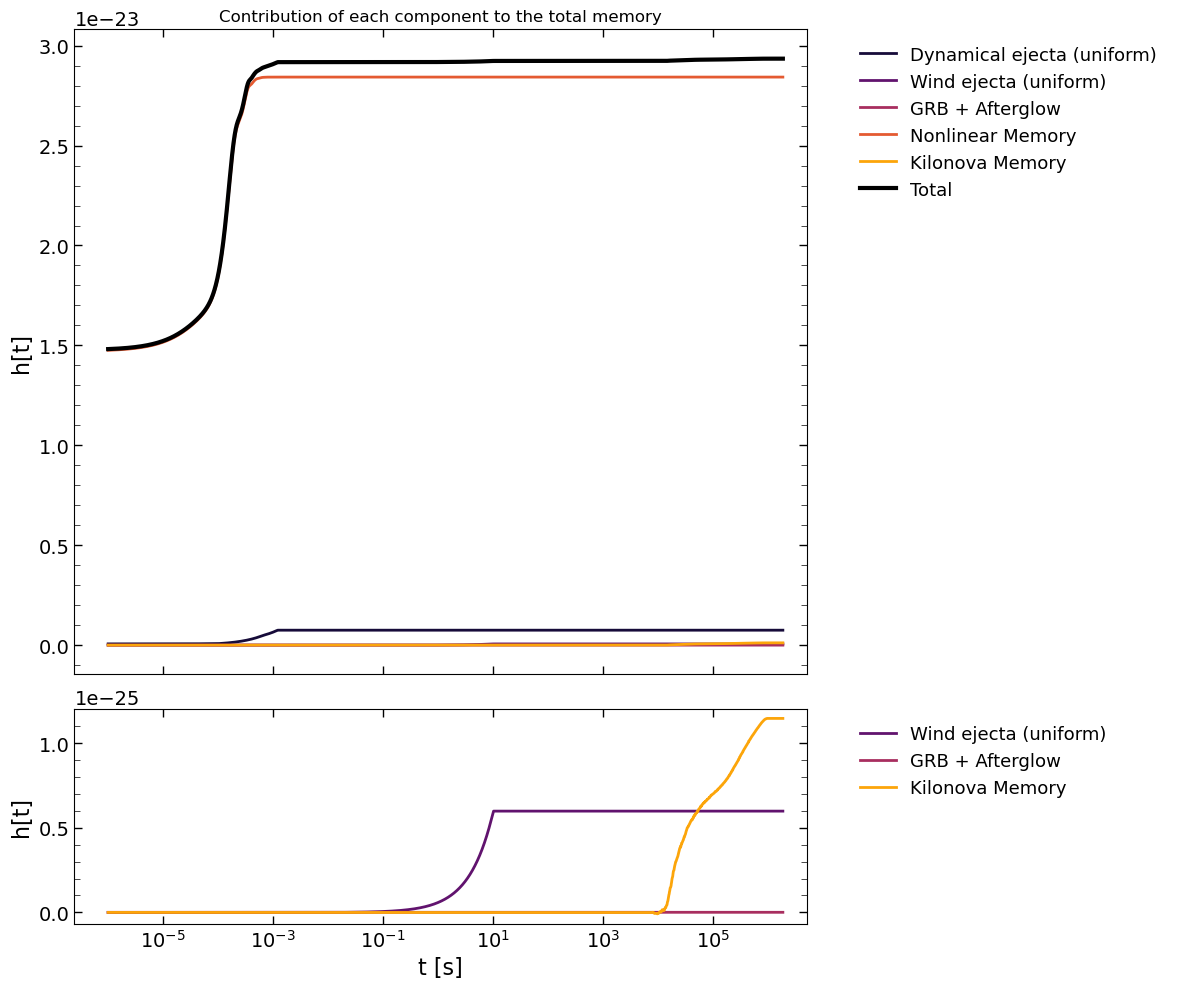

Fréquence de Nyquist estimée : 8.85e+08 Hz


In [ ]:
# Same for linear models of dyn and wind

h_lin_dyn = memory_components['dyn']['h_lin']
h_lin_wind = memory_components['wind']['h_lin']
h_list_lin = [h_lin_dyn, h_lin_wind, memory_components['grb']['h'], memory_components['nonlinear']['h'], memory_components['kilonova']['h']]

labels_lin = ['Dynamical ejecta (uniform) ', 'Wind ejecta (uniform)', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('inferno')
colors_lin = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels_lin))]

# Définir t_min pour la grille log (doit être > 0)
t_min_log = 1e-6  # ou la plus petite valeur positive de t_list
t_max = max([t[-1] for t in t_list])
N_points = int(5e4)

t_common_log = np.logspace(np.log10(t_min_log), np.log10(t_max), N_points)

# Interpolation sur la grille log
h_interp_list = []
for t, h in zip(t_list, h_list_lin):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common_log)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels_lin, colors_lin):
    ax_main.plot(t_common_log, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common_log, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('log')

# Afficher à partir de t = -1 s
ax_main.set_xlim(-1, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common_log, h_interp_list[i], label=labels_lin[i], color=colors_lin[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('log')
ax_inset.set_xlim(-1, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

dt_min = np.min(np.diff(t_common_log))
print(f"Fréquence de Nyquist estimée : {0.5/dt_min:.2e} Hz")

## Plot of the total memory in the frequency domain

TF of the total memory

Sampling frequency: 2.74e-02 Hz, max frequency: 1.37e-02 Hz given by Nyquist


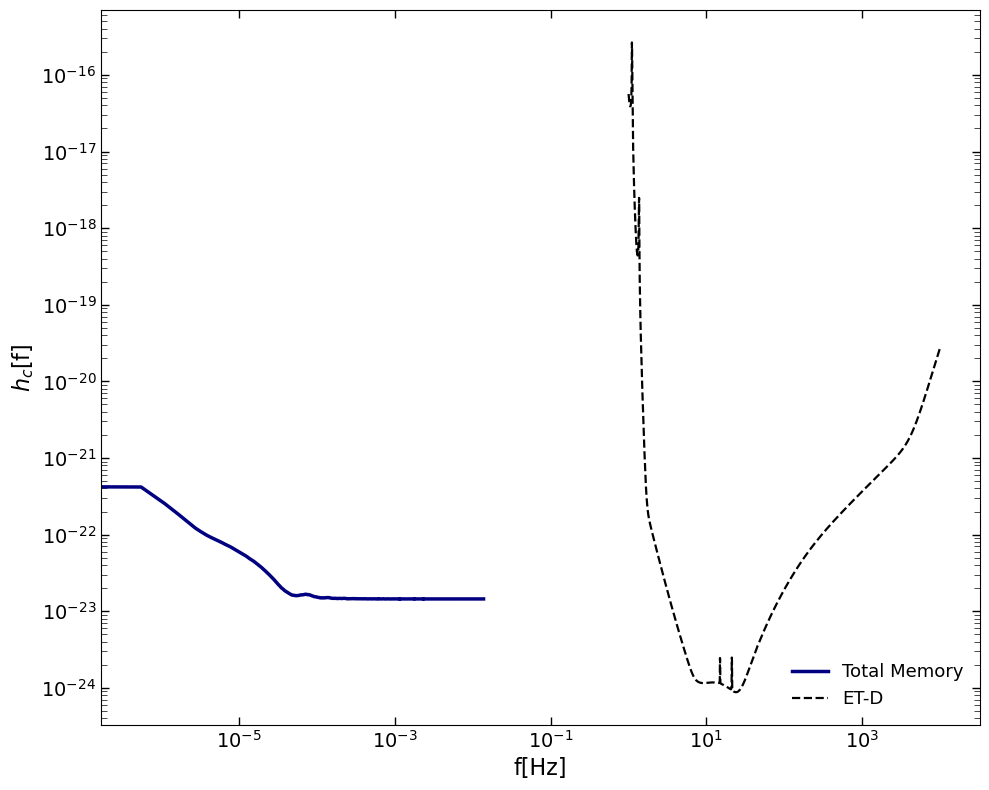

In [21]:
# TF de la somme totale + comparaison avec courbes sensi ET
# use nfft method

t_uniform = np.linspace(t_common_log[0], t_common_log[-1], N_points)
h_uniform = np.interp(t_uniform, t_common_log, h_total)
dt = t_uniform[1] - t_uniform[0]
fft_total = np.fft.rfft(h_uniform)
f_total = np.fft.rfftfreq(len(h_uniform), d=dt)

print(f"Sampling frequency: {1/dt:.2e} Hz, max frequency: {0.5/dt:.2e} Hz given by Nyquist")

plt.figure(figsize=(10, 8))
plt.plot(f_total,  np.abs(fft_total), label='Total Memory', color='navy', lw=2.5)

for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
                 color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                 label=det_label)
plt.xscale('log')
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')


plt.legend(loc = 'lower right', frameon=False, fontsize= 13)
plt.tight_layout()
plt.show()

Sum of each TF

NameError: name 'labels_lin' is not defined

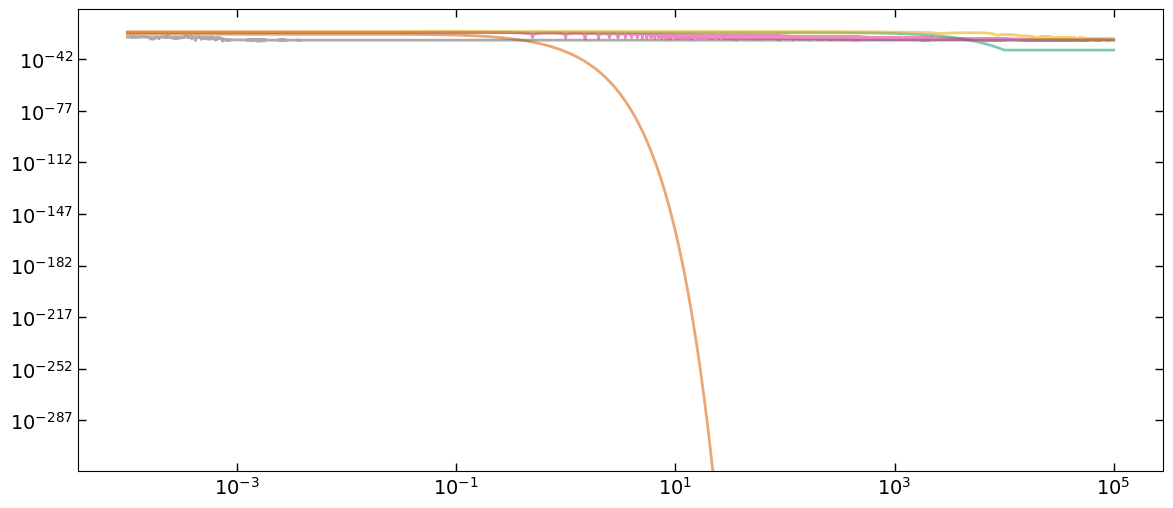

In [14]:
from scipy.interpolate import interp1d

# Grille fréquentielle commune
f_common = np.logspace(-4, 5, 50000)

hc_total = np.zeros_like(f_common)

f_list = [memory_components[key]['f'] for key in memory_components]
fft_list = [memory_components[key]['hc'] for key in memory_components]
f_list_lin = [memory_components[key]['f_lin'] if 'f_lin' in memory_components[key] else memory_components[key]['f'] for key in memory_components]
fft_list_lin = [memory_components[key]['hc_lin'] if 'hc_lin' in memory_components[key] else memory_components[key]['hc'] for key in memory_components]
cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in np.linspace(0, 0.9, len(memory_components))]
labels = list(memory_components.keys())
plt.figure(figsize=(14, 6))
for i, (f_i, hc_i) in enumerate(zip(f_list, fft_list)):
    interp_func = interp1d(f_i, hc_i, kind='linear', bounds_error=False, fill_value=(hc_i[0], hc_i[-1]))
    hc_interp = interp_func(f_common)
    plt.loglog(f_common, hc_interp, label=labels[i], color=colors[i], lw=2, alpha = 0.55)
    hc_interp = np.nan_to_num(hc_interp, nan=0.0, posinf=0.0, neginf=0.0)
    hc_total += hc_interp

for i, (f_i, hc_i) in enumerate(zip(f_list_lin, fft_list_lin)):
    print(labels_lin[i], np.any(np.isnan(f_i)), np.any(np.isnan(hc_i)))
print('hc_total: ', np.any(np.isnan(hc_total)))
# Plot

plt.loglog(f_common, hc_total, label='Total Memory', color='crimson', lw=2.5, zorder=100)
print(f_common[-1], hc_total[-1])
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
               color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
               label=det_label)

plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.xlim(3e-1, 1e5)
plt.ylim(1e-30, 5e-18)
plt.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

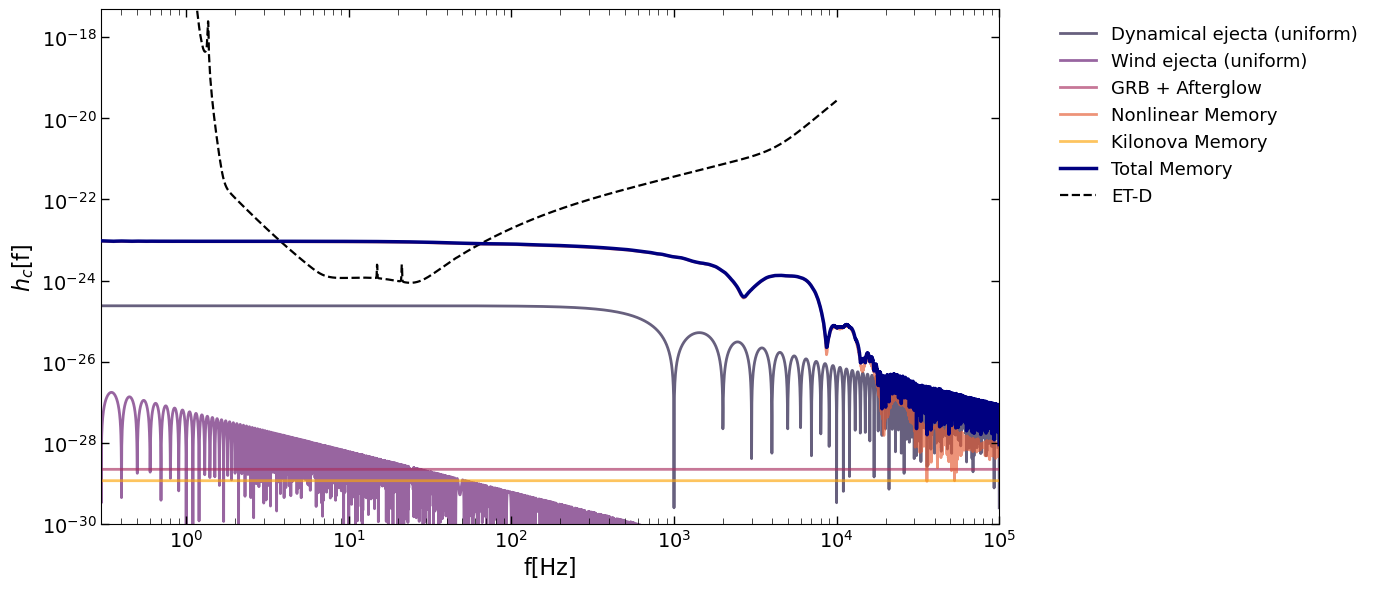

In [ ]:
from scipy.interpolate import interp1d

# Grille fréquentielle commune
f_common_lin = np.logspace(-4, 5, 10000)

# fft_list_lin = [fft_dyn_linear, fft_wind_linear, fft_list[2], fft_list[3], fft_list[4]]
# f_list_lin   = [f_linear_dyn,   f_linear_wind,   f_list[2],   f_list[3],   f_list[4]]


hc_total_lin = np.zeros_like(f_common_lin)

f_list = [memory_components[key]['f'] for key in memory_components]
fft_list = [memory_components[key]['hc'] for key in memory_components]
f_list_lin = [memory_components[key]['f_lin'] if 'f_lin' in memory_components[key] else memory_components[key]['f'] for key in memory_components]
fft_list_lin = [memory_components[key]['hc_lin'] if 'hc_lin' in memory_components[key] else memory_components[key]['hc'] for key in memory_components]
plt.figure(figsize=(14, 6))
for i, (f_i, hc_i) in enumerate(zip(f_list_lin, fft_list_lin)):
    interp_func = interp1d(f_i, hc_i, kind='linear', bounds_error=False, fill_value=(hc_i[0], hc_i[-1]))
    hc_interp = interp_func(f_common_lin)
    plt.loglog(f_common_lin, hc_interp, label=labels_lin[i], color=colors_lin[i], lw=2, alpha=0.65, zorder=-10)
    hc_total_lin += hc_interp

# Plot

plt.loglog(f_common_lin, hc_total_lin, label='Total Memory', color='navy', lw=2.5, zorder=100)

for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
               color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
               label=det_label)

plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.xlim(3e-1, 1e5)
plt.ylim(1e-30, 5e-18)
plt.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## SNR 

In [15]:
# test de différent hc_total pour le calcul de snr
def compute_total_hc(
    f_common,
    params_dyn,
    params_wind,
    params_grb,
    memory_components,
    if_dyn = True,
    if_wind = True,
    if_grb = True,
    if_nonlin = True,
    if_kilonova = True
):
    """
    Calcule la somme des hc interpolés sur f_common pour chaque composant de mémoire.
    Les composants nonlinéaire et kilonova sont récupérés directement du dict memory_components.
    Les autres sont recalculés à partir des paramètres fournis.

    params_dyn: dict, paramètres pour dyn (ex: {'M_ej':..., 'v_ej':..., 'tau':..., 'r':..., 'start':..., 'model':...})
    params_wind: dict, idem pour wind
    params_grb: dict, paramètres pour grb+afterglow (ex: {'E_grb':..., 'theta':..., 'phi_ej':..., 'r':..., 'beta':..., 'end_grb':..., 'P_in':..., 'theta_j':...})
    memory_components: dict, contient déjà 'nonlinear' et 'kilonova' avec leurs 'f' et 'hc'
    f_common: array, grille fréquentielle commune

    Retourne: hc_total (array, même taille que f_common)
    """

    hc_total = np.zeros_like(f_common)
    # Dynamical ejecta
    t_dyn = np.linspace(-5., 50., 100000)
    h_dyn = up.linear_memory_ejecta_masked(
        t_dyn,
        params_dyn['M_ej'],
        params_dyn['v_ej'],
        params_dyn['tau'],
        params_dyn['r'],
        params_dyn['start'],
        model=params_dyn.get('model', 'exponential')
    )
    f_dyn, fft_dyn = up.fft_exp_model(h_dyn[-1], params_dyn['tau'])
    hc_dyn = 2 * f_dyn * np.abs(fft_dyn)
    interp_dyn = interp1d(f_dyn, hc_dyn, kind='linear', bounds_error=False, fill_value=(hc_dyn[0], hc_dyn[-1]))
    interp_dyn = np.nan_to_num(interp_dyn, nan=0.0, posinf=0.0, neginf=0.0)
    if if_dyn:
        hc_total += interp_dyn(f_common)

    t_wind = np.linspace(-5., 50., 100000)
    h_wind = up.linear_memory_ejecta_masked(
        t_wind,
        params_wind['M_ej'],
        params_wind['v_ej'],
        params_wind['tau'],
        params_wind['r'],
        params_wind['start'],
        model=params_wind.get('model', 'exponential')
    )
    f_wind, fft_wind = up.fft_exp_model(h_wind[-1], params_wind['tau'])
    hc_wind = 2 * f_wind * np.abs(fft_wind)
    hc_wind = np.nan_to_num(hc_wind, nan=0.0, posinf=0.0, neginf=0.0)  

    interp_wind = interp1d(f_wind, hc_wind, kind='linear', bounds_error=False, fill_value=(hc_wind[0], hc_wind[-1]))
    hc_interp_wind = interp_wind(f_common)
    hc_interp_wind = np.nan_to_num(hc_interp_wind, nan=0.0, posinf=0.0, neginf=0.0)  

    if if_wind:
        hc_total += hc_interp_wind

    # GRB + Afterglow
    h_in = up.memory_initial_acceleration_GRB(
        params_grb['E_grb'],
        params_grb['theta'],
        params_grb['phi_ej'],
        params_grb['r'],
        params_grb['beta']
    )
    h_aft = ugrb.memory_afterglow(
        params_grb['E_aft'], 
        params_grb['theta'],
        params_grb['phi_ej'],
        params_grb['r'],
        params_grb['beta']
    )
    t_grb = np.linspace(-5., 50., 100000)
    h_tot, _ = up.memory_total_waveform(t_grb, h_in, h_aft, params_grb['end_grb'], params_grb['theta'])
    f_grb, fft_grb_aft = up.new_fft(h_in, h_aft, params_grb['end_grb'], params_grb['theta'])
    hc_grb = 2 * f_grb * np.abs(fft_grb_aft)
    interp_grb = interp1d(f_grb, hc_grb, kind='linear', bounds_error=False, fill_value=(hc_grb[0], hc_grb[-1]))
    interp_grb = np.nan_to_num(interp_grb, nan=0.0, posinf=0.0, neginf=0.0)
    if if_grb:
        hc_total += interp_grb(f_common)

    # Nonlinear memory (déjà calculé)
    f_nl = memory_components['nonlinear']['f']
    hc_nl = memory_components['nonlinear']['hc']
    interp_nl = interp1d(f_nl, hc_nl, kind='linear', bounds_error=False, fill_value=(hc_nl[0], hc_nl[-1]))
    if if_nonlin:
        hc_total += interp_nl(f_common)

    # Kilonova (déjà calculé)
    f_kn = memory_components['kilonova']['f']
    hc_kn = memory_components['kilonova']['hc']
    interp_kn = interp1d(f_kn, hc_kn, kind='linear', bounds_error=False, fill_value=(hc_kn[0], hc_kn[-1]))
    if if_kilonova:
        hc_total += interp_kn(f_common)


    return hc_total

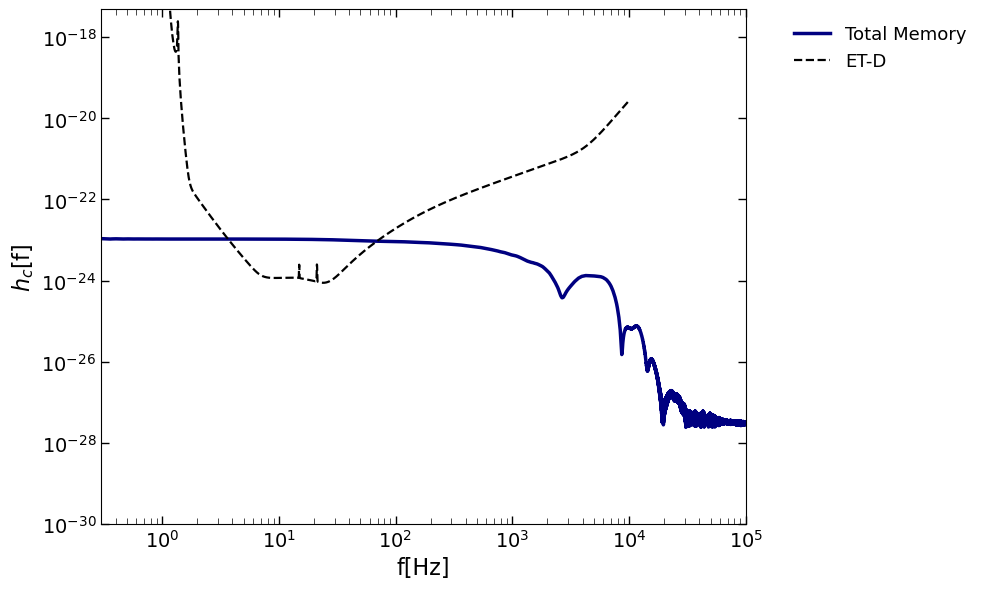

In [16]:
params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
params_grb = {'E_grb': 3e47, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'E_aft': 1e52, 'theta_j': np.deg2rad(5)}
f = np.logspace(-4, 5, 50000)
hc_total_1 = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components)
plt.figure(figsize=(10, 6))
plt.loglog(f, hc_total_1, label='Total Memory', color='navy', lw=2.5)
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
               color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
               label=det_label)
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.xlim(3e-1, 1e5)
plt.ylim(1e-30, 5e-18)
plt.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [17]:
from scipy.interpolate import interp1d
def compute_snr(f_signal, h_c, f_noise, h_n):
    f_signal = np.array(f_signal)
    h_c = np.array(h_c)
    f_noise = np.array(f_noise)
    h_n = np.array(h_n)

    interp_hn = interp1d(f_noise, h_n, kind='linear', bounds_error=False)
    h_n_interp = interp_hn(f_signal)
    
    # we compute the snr only for freq between 1e0 and 1e4 Hz to avoid issues with extrapolation
    mask = (f_signal >= 1e0) & (f_signal <= 1e4)
    f_signal = f_signal[mask]
    h_c = h_c[mask]
    h_n_interp = h_n_interp[mask]

    integrand = (h_c**2) / (h_n_interp**2)
    snr_squared = np.trapezoid(integrand, x=np.log(f_signal))
    snr = np.sqrt(snr_squared)
    return snr

In [16]:
et_d_data = et_sensitivities['ET-D']
f_noise = et_d_data[:, 0]
h_n = et_d_data[:, 1]
snr_1 = compute_snr(f, hc_total_1, f_noise, h_n)

print(f"SNR for total memory with ET-D: {snr_1:.2f}")

NameError: name 'hc_total_1' is not defined

In [20]:
hc_no_nl = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components, if_nonlin=False, if_dyn=True)
snr_no_nl = compute_snr(f, hc_no_nl, f_noise, h_n)
print(f"SNR without nonlinear memory: {snr_no_nl:.5f}")

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: overflow encountered in sinh
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in multiply
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in divide
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))


SNR without nonlinear memory: 1.82299


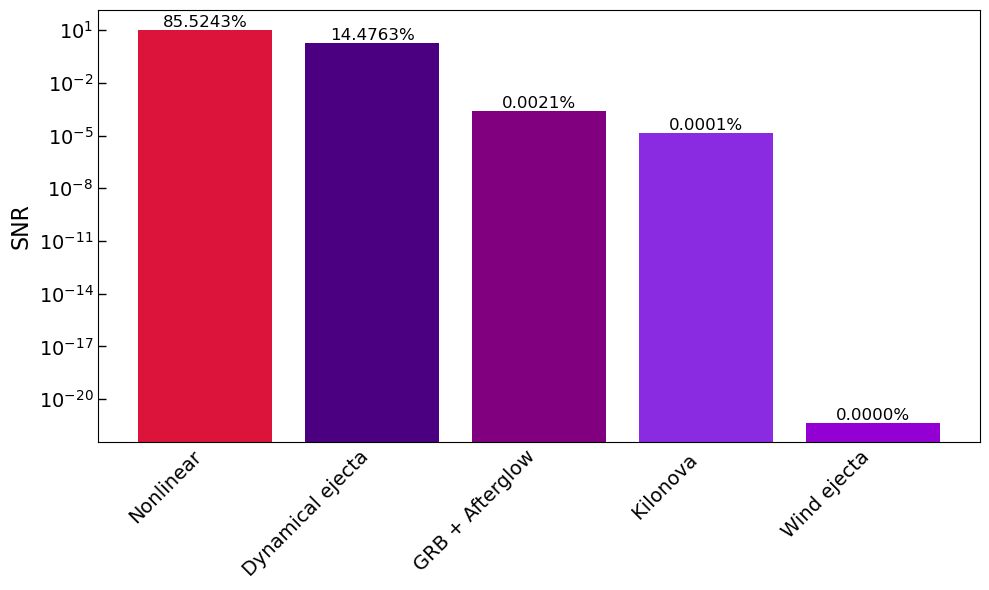

In [41]:
# ET-D configuration
et_d_data = et_sensitivities['ET-D']
f_noise = et_d_data[:, 0]
h_n = et_d_data[:, 1]
hc_nonlin = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components, if_dyn=False, if_wind=False, if_grb=False, if_nonlin=True, if_kilonova=False)
snr_nonlin = compute_snr(f, hc_nonlin, f_noise, h_n)

hc_kilonova = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components, if_dyn=False, if_wind=False, if_grb=False, if_nonlin=False, if_kilonova=True)
snr_kilonova = compute_snr(f, hc_kilonova, f_noise, h_n)

hc_dyn = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components, if_dyn=True, if_wind=False, if_grb=False, if_nonlin=False, if_kilonova=False)
snr_dyn = compute_snr(f, hc_dyn, f_noise, h_n)

hc_wind = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components, if_dyn=False, if_wind=True, if_grb=False, if_nonlin=False, if_kilonova=False)
snr_wind = compute_snr(f, hc_wind, f_noise, h_n)

hc_grb = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components, if_dyn=False, if_wind=False, if_grb=True, if_nonlin=False, if_kilonova=False)
snr_grb = compute_snr(f, hc_grb, f_noise, h_n)

# bar plot for snr of each component in log scale
components = ['Dynamical ejecta', 'Wind ejecta', 'GRB + Afterglow', 'Nonlinear', 'Kilonova ']
snr_values = [snr_dyn, snr_wind, snr_grb, snr_nonlin, snr_kilonova]

# compute relative contribution of each component to the total snr
snr_total = snr_1
relative_contributions = [snr / snr_total for snr in snr_values]
# sort 
relative_contributions, components, snr_values = zip(*sorted(zip(relative_contributions, components, snr_values), reverse=True))
colors=['#DC143C', "#4B0082",'#800080', '#8A2BE2', '#9400D3']
plt.figure(figsize=(10, 6))
bars = plt.bar(components, snr_values, color=colors)
plt.yscale('log')
plt.ylabel('SNR')

plt.xticks(rotation=45, ha='right')
# Annotate bars with relative contribution in percentage
for bar, rel in zip(bars, relative_contributions):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{rel*100:.4f}%', ha='center', va='bottom', fontsize=12)
plt.minorticks_off()
plt.tick_params(axis='both', which='both', left=True, right=False, top = False, bottom=False)
plt.tight_layout()
plt.show()


Map de SNR

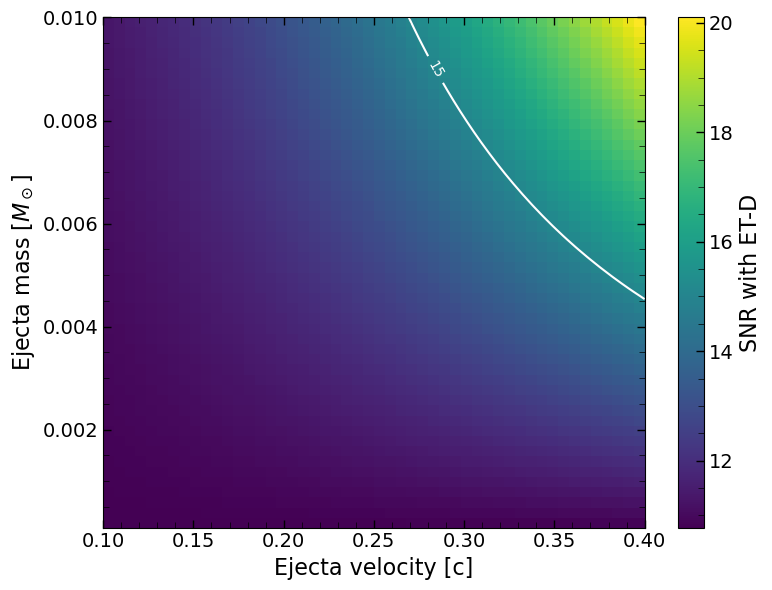

In [27]:
# Test 1 : different mass /velocity of ejecta for the dynamical component
M_ej_values = np.linspace(1e-4, 1e-2, 50)  # in solar masses
v_ej_values = np.linspace(0.1, 0.4, 50)  # in c
snr_results = np.zeros((len(M_ej_values), len(v_ej_values)))
for i, M_ej in enumerate(M_ej_values):
    for j, v_ej in enumerate(v_ej_values):
        params_dyn = {'M_ej': M_ej, 'v_ej': v_ej, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
        params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
        params_grb = {'E_grb': 3e47, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
        hc_total_test = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components)
        snr_results[i, j] = compute_snr(f_common, hc_total_test, f_noise, h_n)
# Plot heatmap of SNR as a function of M_ej and v_ej
plt.figure(figsize=(8, 6))
plt.imshow(snr_results, extent=(v_ej_values[0], v_ej_values[-1], M_ej_values[0], M_ej_values[-1]), aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar(label='SNR with ET-D')
plt.xlabel('Ejecta velocity [c]')
plt.ylabel(r'Ejecta mass [$M_\odot$]')


# Ajout des isobars 
levels = [1, 5, 10,  15]
contours = plt.contour(v_ej_values, M_ej_values, snr_results, levels=levels, colors='white')
plt.clabel(contours, inline=True, fontsize=10, fmt='%d')
plt.tight_layout()
plt.show()

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: overflow encountered in sinh
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in multiply
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in divide
  h_f =  (delta_h *np.pi * tau)/(1j*np.sinh( np.pi * f * tau))


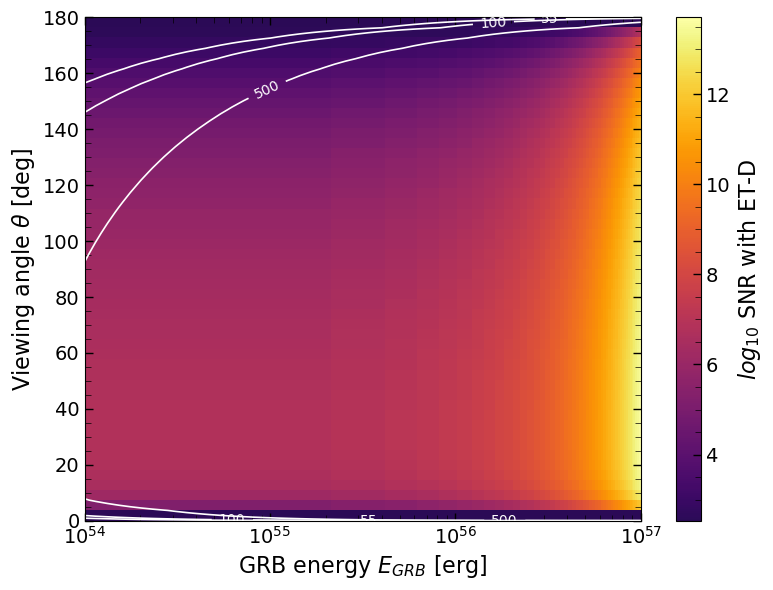

In [31]:
# Paramètres pour le test
theta_values = np.linspace(0, np.pi, 50)  # in radians
E_grb_values = np.logspace(54, 57, 50)

theta_grid, E_grid = np.meshgrid(theta_values, E_grb_values, indexing='ij')
snr_results_grb = np.zeros_like(theta_grid)

for i in range(theta_grid.shape[0]):
    for j in range(theta_grid.shape[1]):
        theta = theta_grid[i, j]
        E_grb = E_grid[i, j]
        params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
        params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
        params_grb = {'E_grb': E_grb, 'theta': theta, 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
        hc_total_test = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components)
        snr_results_grb[i, j] = compute_snr(f_common, hc_total_test, f_noise, h_n)

theta_deg_values = np.degrees(theta_values)
theta_deg_grid = np.degrees(theta_grid)

# Plot
import matplotlib.colors as mcolors
cmap_base = plt.get_cmap('inferno')
cmap_trunc = mcolors.LinearSegmentedColormap.from_list(
    'trunc_inferno', 
    cmap_base(np.linspace(0.15, 1, 256))
)

plt.figure(figsize=(8, 6))
im = plt.imshow(
    np.log(snr_results_grb),
    extent=(E_grb_values[0], E_grb_values[-1], theta_deg_values[0], theta_deg_values[-1]),
    aspect='auto',
    origin='lower',
    cmap=cmap_trunc,
    interpolation='nearest'
)

plt.colorbar(label=r'$log_{10}$ SNR with ET-D')
plt.xlabel(r'GRB energy $E_{GRB}$ [erg]')
plt.ylabel(r'Viewing angle $\theta$ [deg]')

plt.xscale('log')

# Ajout des isobars 
levels = [1, 5, 10,  55, 100, 500]
contours = plt.contour(
    E_grid, theta_deg_grid, snr_results_grb, levels=levels, colors='white', linewidths=1.2
)
plt.clabel(contours, inline=True, fontsize=10, fmt='%d')
plt.tight_layout()

plt.show()

SNR min: 12.617550856149135 SNR max: 12.617550856149135


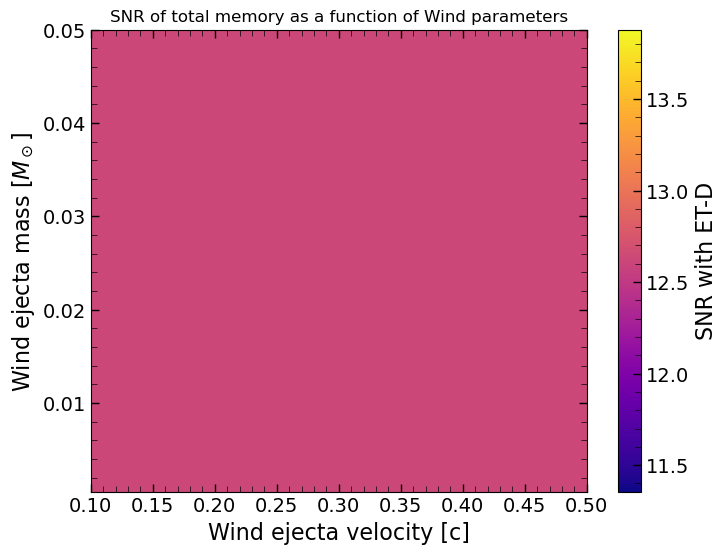

In [29]:
# Paramètres pour le test
M_ej_wind_values = np.linspace(5e-4, 5e-2, 50)  # in solar masses
v_ej_wind_values = np.linspace(0.1, 0.5, 50)  # in c
Me_j_grid, v_ej_grid = np.meshgrid(M_ej_wind_values, v_ej_wind_values, indexing='ij')
snr_results_wind = np.zeros_like(Me_j_grid)
for i in range(Me_j_grid.shape[0]):
    for j in range(Me_j_grid.shape[1]):
        M_ej_wind = Me_j_grid[i, j]
        v_ej_wind = v_ej_grid[i, j]
        # ! change E_grb to e49 
        params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
        params_wind = {'M_ej': M_ej_wind, 'v_ej': v_ej_wind, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
        params_grb = {'E_grb': 3e49, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
        hc_total_test = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components)
        snr_results_wind[i, j] = compute_snr(f_common, hc_total_test, f_noise, h_n)


print('SNR min:', np.min(snr_results_wind), 'SNR max:', np.max(snr_results_wind))

plt.figure(figsize=(8, 6))
im = plt.imshow(
    snr_results_wind,
    extent=(v_ej_wind_values[0], v_ej_wind_values[-1], M_ej_wind_values[0], M_ej_wind_values[-1]),
    aspect='auto',
    origin='lower',
    cmap='plasma', 
    interpolation='nearest'
)
plt.colorbar(label='SNR with ET-D')
plt.xlabel(r'Wind ejecta velocity [c]')
plt.ylabel(r'Wind ejecta mass [$M_\odot$]')
plt.title('SNR of total memory as a function of Wind parameters')

# Choisis des niveaux adaptés à ta plage de SNR
levels = [1, 5]
contours = plt.contour(
    v_ej_grid, Me_j_grid, snr_results_wind, levels=levels, colors='white', linewidths=1.2
)
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f')

plt.show()

Petit impact sur le SNR 

### Test for the total waveform with/without nonlinear memory

In [12]:
# modify a bit the compute_total_hc function to return also the individual hc of each component
# modify also the nonlinear and kilonova components to scale with distance (1/r)
# and add an option to not include them in the total if we want to test only the linear components
def compute_total_hc(
    f_common,
    params_dyn,
    params_wind,
    params_grb,
    memory_components, 
    add_nonlinear = True,
    add_kilonova = True
):
    """
    Calcule la somme des hc interpolés sur f_common pour chaque composant de mémoire.
    Les composants nonlinéaire et kilonova sont récupérés directement du dict memory_components.
    Les autres sont recalculés à partir des paramètres fournis.

    params_dyn: dict, paramètres pour dyn (ex: {'M_ej':..., 'v_ej':..., 'tau':..., 'r':..., 'start':..., 'model':...})
    params_wind: dict, idem pour wind
    params_grb: dict, paramètres pour grb+afterglow (ex: {'E_grb':..., 'theta':..., 'phi_ej':..., 'r':..., 'beta':..., 'end_grb':..., 'P_in':..., 'theta_j':...})
    memory_components: dict, contient déjà 'nonlinear' et 'kilonova' avec leurs 'f' et 'hc'
    f_common: array, grille fréquentielle commune

    Retourne: hc_total (array, même taille que f_common)
    """

    hc_total = np.zeros_like(f_common)
    # Dynamical ejecta
    t_dyn = np.linspace(-5., 50., 100000)
    h_dyn = up.linear_memory_ejecta_masked(
        t_dyn,
        params_dyn['M_ej'],
        params_dyn['v_ej'],
        params_dyn['tau'],
        params_dyn['r'],
        params_dyn['start'],
        model=params_dyn.get('model', 'exponential')
    )
    f_dyn, fft_dyn = up.fft_exp_model(h_dyn[-1], params_dyn['tau'])
    hc_dyn = 2 * f_dyn * np.abs(fft_dyn)
    interp_dyn = interp1d(f_dyn, hc_dyn, kind='linear', bounds_error=False, fill_value=(hc_dyn[0], hc_dyn[-1]))
    interp_dyn = np.nan_to_num(interp_dyn, nan=0.0, posinf=0.0, neginf=0.0)

    hc_total += interp_dyn(f_common)

    t_wind = np.linspace(-5., 50., 100000)
    h_wind = up.linear_memory_ejecta_masked(
        t_wind,
        params_wind['M_ej'],
        params_wind['v_ej'],
        params_wind['tau'],
        params_wind['r'],
        params_wind['start'],
        model=params_wind.get('model', 'exponential')
    )
    f_wind, fft_wind = up.fft_exp_model(h_wind[-1], params_wind['tau'])
    hc_wind = 2 * f_wind * np.abs(fft_wind)
    hc_wind = np.nan_to_num(hc_wind, nan=0.0, posinf=0.0, neginf=0.0)  

    interp_wind = interp1d(f_wind, hc_wind, kind='linear', bounds_error=False, fill_value=(hc_wind[0], hc_wind[-1]))
    hc_interp_wind = interp_wind(f_common)
    hc_interp_wind = np.nan_to_num(hc_interp_wind, nan=0.0, posinf=0.0, neginf=0.0)  


    hc_total += hc_interp_wind

    # GRB + Afterglow
    h_in = up.memory_initial_acceleration_GRB(
        params_grb['E_grb'],
        params_grb['theta'],
        params_grb['phi_ej'],
        params_grb['r'],
        params_grb['beta']
    )
    h_aft = up.memory_afterglow_injection(
        params_grb['P_in'],
        params_grb['end_grb'],
        params_grb['theta'],
        params_grb['theta_j'],
        params_grb['r'],
        params_grb['beta']
    )
    t_grb = np.linspace(-5., 50., 100000)
    h_tot, _ = up.memory_total_waveform(t_grb, h_in, h_aft, params_grb['end_grb'], params_grb['theta'])
    f_grb, fft_grb_aft = up.new_fft(h_in, h_aft, params_grb['end_grb'], params_grb['theta'])
    hc_grb = 2 * f_grb * np.abs(fft_grb_aft)
    interp_grb = interp1d(f_grb, hc_grb, kind='linear', bounds_error=False, fill_value=(hc_grb[0], hc_grb[-1]))
    interp_grb = np.nan_to_num(interp_grb, nan=0.0, posinf=0.0, neginf=0.0)

    hc_total += interp_grb(f_common)
    if add_nonlinear:
        # Nonlinear memory (déjà calculé)
        f_nl = memory_components['nonlinear']['f']
        hc_nl = memory_components['nonlinear']['hc']
        hc_nl_scaled = hc_nl * (40e6 / params_grb['r']) # assume it scales as 1/r (r in pc)
        interp_nl = interp1d(f_nl, hc_nl_scaled, kind='linear', bounds_error=False, fill_value=(hc_nl[0], hc_nl[-1]))
    
        hc_total += interp_nl(f_common)
    # Kilonova (déjà calculé)
    if add_kilonova:
        f_kn = memory_components['kilonova']['f']
        hc_kn = memory_components['kilonova']['hc']
        # has been computed for a distance of 40 Mpc, so we have to scale it for others distances
        hc_kn_scaled = hc_kn * (40e6 / params_grb['r']) # assume it scales as 1/r (r in pc)
        interp_kn = interp1d(f_kn, hc_kn_scaled, kind='linear', bounds_error=False, fill_value=(hc_kn[0], hc_kn[-1]))

        hc_total += interp_kn(f_common)


    return hc_total

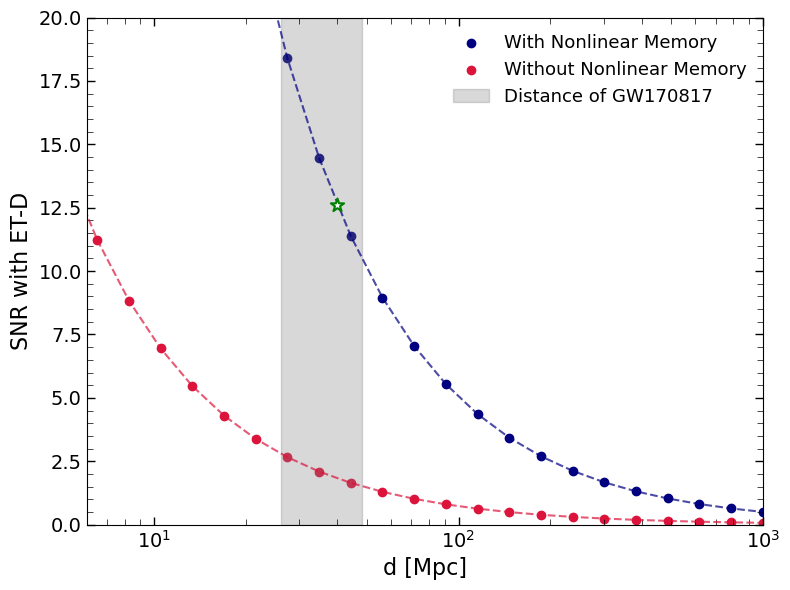

SNR at 40 Mpc with nonlinear memory: 11.38
SNR at 40 Mpc without nonlinear memory: 1.64821


In [24]:
# compute and compare the SNR with and without the nonlinear component for different distances
distances = np.logspace(6.5, 9, 25)  
snr_with_nl = []
snr_without_nl = []
f_common = np.logspace(-4, 5, 50000)
for r in distances:
    params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': r, 'start': -1e-3, 'model': 'exponential'}
    params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': r, 'start': 0.01, 'model': 'exponential'}
    params_grb = {'E_grb': 3e47, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': r, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
    hc_total_with_nl = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components, add_nonlinear=True)
    hc_total_without_nl = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components, add_nonlinear=False)
    snr_with_nl.append(compute_snr(f_common, hc_total_with_nl, f_noise, h_n))
    snr_without_nl.append(compute_snr(f_common, hc_total_without_nl, f_noise, h_n))
plt.figure(figsize=(8, 6))
plt.scatter(distances / 1e6, snr_with_nl, label='With Nonlinear Memory', color='navy')
plt.plot(distances / 1e6, snr_with_nl, color='navy', lw=1.5, alpha=0.7, ls = '--')
plt.scatter(distances / 1e6, snr_without_nl, label='Without Nonlinear Memory', color='crimson')
plt.plot(distances / 1e6, snr_without_nl, color='crimson', lw=1.5, alpha=0.7, ls = '--')

min_dist = 40-14
max_dist = 40+8
plt.fill_betweenx([0, 20], min_dist, max_dist, color='grey', alpha=0.3, label='Distance of GW170817')
plt.scatter(40, 12.59, label='', color='white', s=100, marker='*', zorder=10, edgecolors='green', linewidths=1.5) # snr computed previously fro 170817
plt.xscale('log')
plt.xlabel('d [Mpc]')
plt.ylabel('SNR with ET-D')
plt.legend(loc = 'upper right', frameon=False, fontsize=13)
plt.ylim(0, 20)
plt.xlim(6, 1e3)
plt.tight_layout()
plt.show()

# print la valeur du snr pour la distance de 40 Mpc avec et sans le composant nonlinéaire
index_40mpc = np.argmin(np.abs(distances - 40e6))
print(f"SNR at 40 Mpc with nonlinear memory: {snr_with_nl[index_40mpc]:.2f}")
print(f"SNR at 40 Mpc without nonlinear memory: {snr_without_nl[index_40mpc]:.5f}")

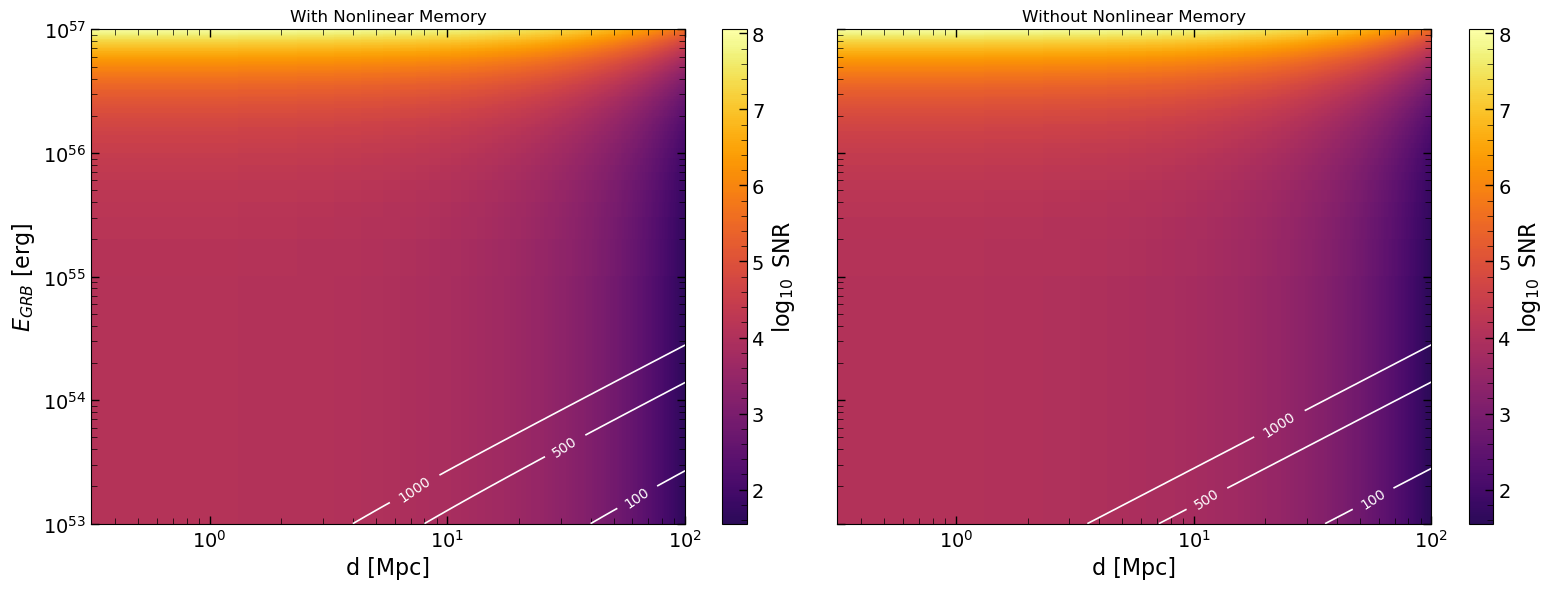

In [32]:
import matplotlib.colors as mcolors
# heatmap for the SNR as a function of distance and E_grb, with and without nonlinear memory solely
E_grb_values = np.logspace(53, 57, 100)
distance_values = np.logspace(5.5, 8, 100)
snr_grid_with_nl = np.zeros((len(E_grb_values), len(distance_values)))
snr_grid_without_nl = np.zeros_like(snr_grid_with_nl)
for i, E_grb in enumerate(E_grb_values):
    for j, r in enumerate(distance_values):
        params_dyn = {'M_ej': 0, 'v_ej': 0, 'tau': 1e-3, 'r': r, 'start': -1e-3, 'model': 'exponential'} # no dyn
        params_wind = {'M_ej': 0, 'v_ej': 0, 'tau': 10, 'r': r, 'start': 0.01, 'model': 'exponential'} # no wind
        # assume Pin = 0.5*E_grb for the grb afterglow injection (just for a test ) ?
        params_grb = {'E_grb': E_grb, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': r, 'beta': 0.99, 'end_grb': 2, 'P_in': 0.5*E_grb, 'theta_j': np.deg2rad(5)}
        # and no kilonova
        hc_total_with_nl = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components, add_nonlinear=True, add_kilonova=False)
        hc_total_without_nl = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components, add_nonlinear=False, add_kilonova=False)
        snr_grid_with_nl[i, j] = compute_snr(f_common, hc_total_with_nl, f_noise, h_n)
        snr_grid_without_nl[i, j] = compute_snr(f_common, hc_total_without_nl, f_noise, h_n)
        
# vmin/vmax for the color scale
log_snr_with_nl = np.log10(snr_grid_with_nl)
log_snr_without_nl = np.log10(snr_grid_without_nl)
vmin = min(np.nanmin(log_snr_with_nl), np.nanmin(log_snr_without_nl))
vmax = max(np.nanmax(log_snr_with_nl), np.nanmax(log_snr_without_nl))

# Colormap tronquée
cmap_base = plt.get_cmap('inferno')
cmap_trunc = mcolors.LinearSegmentedColormap.from_list(
    'trunc_inferno', 
    cmap_base(np.linspace(0.15, 1, 256))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

im1 = axes[0].imshow(
    log_snr_with_nl,
    extent=(distance_values[0] / 1e6, distance_values[-1] / 1e6, E_grb_values[0], E_grb_values[-1]),
    aspect='auto',
    origin='lower',
    cmap=cmap_trunc,
    interpolation='nearest',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_xscale('log')
axes[0].set_xlabel('d [Mpc]')
axes[0].set_title('With Nonlinear Memory')
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$E_{GRB}$ [erg]')
fig.colorbar(im1, ax=axes[0], label=r'$\log_{10}$ SNR')

levels = [1, 5, 10, 100, 500, 1000]
contours1 = axes[0].contour(
    distance_values / 1e6, E_grb_values, snr_grid_with_nl, levels=levels, colors='white', linewidths=1.2
)
axes[0].clabel(contours1, inline=True, fontsize=10, fmt='%d')

im2 = axes[1].imshow(
    log_snr_without_nl,
    extent=(distance_values[0] / 1e6, distance_values[-1] / 1e6, E_grb_values[0], E_grb_values[-1]),
    aspect='auto',
    origin='lower',
    cmap=cmap_trunc,
    interpolation='nearest',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Without Nonlinear Memory')
axes[1].set_xlabel('d [Mpc]')
fig.colorbar(im2, ax=axes[1], label=r'$\log_{10}$ SNR')

contours2 = axes[1].contour(
    distance_values / 1e6, E_grb_values, snr_grid_without_nl, levels=levels, colors='white', linewidths=1.2
)
axes[1].clabel(contours2, inline=True, fontsize=10, fmt='%d')

plt.tight_layout()
plt.show()

## GRBS + afterglow 

In this part, we compute the total memory signal for a GRB, including both the initial memory from the prompt emission and the afterglow contribution. We will use the phenomenological model described in [this paper](https://arxiv.org/pdf/2301.12590) for different GRBs, and we will compute the total memory signal for each GRB, as well as the corresponding SNR in LISA.

1. BOAT + afterglow
2. ULGRBs (day-long or ~4.2h ? ~7h with 3 episodes equaly spaced ?) of GRB 250702BD : https://arxiv.org/pdf/2507.14286 - https://arxiv.org/pdf/2509.26283 

3. Closest GRB : GRB 980425/SN 1998bw. Located at a distance of 36.9 Mpc 
    - E_tot ?= 1e48 erg (obtained via a special model : https://www.sciencedirect.com/science/article/pii/S0273117704006295)
    - E_iso ?= 6e47 erg (https://scispace.com/pdf/an-off-axis-jet-model-for-grb-980425-and-low-energy-gamma-7cxl121i2s.pdf) with a jet half opening angle $\Delta\theta$:  10°<= $\Delta \theta$ <=30°
4. GRB 170817A + afterglow


Table of the different parameters for the GRBs:

| GRB | Distance (Mpc/ z) | Energy_iso prompt (erg) | Energy_iso afterglow (erg) | Duration [not in the rest frame (should divide by (1+z))] (s) | half jet opening angle (°) | Inclination angle (°) |
| --- | --- | --- | --- | --- | --- | --- |
| BOAT | 724 Mpc | 1e55 | $\le 3 \times 1e{54}$ [ref_page_3](https://arxiv.org/pdf/2306.06372)  | 600 | $1.4e-2 $ rad [ref](https://arxiv.org/pdf/2407.03743) | $9.4e-4 - 5.9e-3$ rad [ref](https://arxiv.org/pdf/2407.03743)  |
| GRB 250702B [ref](https://arxiv.org/pdf/2509.22792#page=5.45) | z~ 1.036 | 2.2e54  [ref](https://arxiv.org/pdf/2509.22778v1) | $8 \times 1e54$ [ref_3.1](https://arxiv.org/pdf/2509.22778v1) | ~ 7h (~ 25 000 s) with 3 episodes equally spaced | $\le 1$ [ref_2.5 Intrinsic Energetics](https://arxiv.org/pdf/2509.22792#page=5.45) or 0.5°[ref](https://arxiv.org/pdf/2509.22778)| 65 deg ? |
| GRB 980425/SN 1998bw [ref](https://arxiv.org/pdf/2105.05067) | 36.9 Mpc | 6e47 |  $1e49$ [paragraphe_above_eq15](https://arxiv.org/pdf/astro-ph/9903483)| 30 | $18^\circ \le \theta_j \le 31^\circ$| $24^\circ \le \theta \le 35^\circ$ |
| GRB 170817A | 40 Mpc | 3e46 | 1e52.2 [ref-tab2](https://arxiv.org/pdf/1811.11491)[ref_aussi_ici](https://www.aanda.org/articles/aa/pdf/2019/08/aa35831-19.pdf) | 2 | ~0.3~ | 32 |

### Afterglow amplitude : 
- Max energy : 1e56 erg
- Min energy : 1e50 erg (conservative value)

As it is complex to determine the energy value for the afterglow, we will consider a range of values for the energy of the afterglow, from 1e50 erg to 1e56 erg distributed uniformly, and we will *randomly* select one of these values to compute the memory signal for the afterglow.

Processing BOAT with E_grb=1.00e+55 erg, d=724.00 Mpc, duration=600.00 s, E_aft=3.00e+54 erg
  Initial GRB memory amplitude: 8.47e-25
  Afterglow memory amplitude: 1.27e-25


/home/stu_brabant/Memory_effect/All_memory/LISA.py:104: RuntimeWarning: overflow encountered in exp
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))
/home/stu_brabant/Memory_effect/All_memory/LISA.py:104: RuntimeWarning: invalid value encountered in multiply
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))


Processing GRB 250702BD with E_grb=1.40e+54 erg, d=7093.76 Mpc, duration=25200.00 s, E_aft=8.00e+54 erg
  Initial GRB memory amplitude: 1.46e-23
  Afterglow memory amplitude: 4.18e-23
Processing GRB 980425 with E_grb=6.00e+47 erg, d=36.90 Mpc, duration=30.00 s, E_aft=1.00e+49 erg
  Initial GRB memory amplitude: 1.50e-27
  Afterglow memory amplitude: 1.25e-26
Processing GRB 170817A with E_grb=3.00e+46 erg, d=40.00 Mpc, duration=2.00 s, E_aft=1.58e+52 erg
  Initial GRB memory amplitude: 6.89e-29
  Afterglow memory amplitude: 1.82e-23


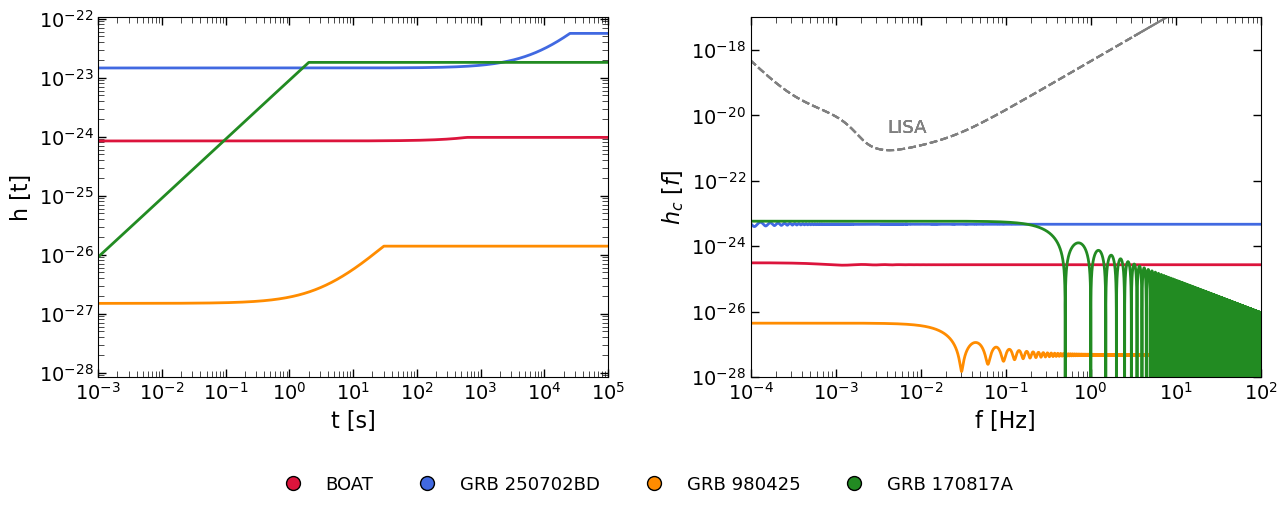

In [11]:
import astropy.units as u
from astropy.cosmology import Planck18
import numpy as np
import matplotlib.pyplot as plt
import utils_GRB_afterglow_phenom as u_grb
np.random.seed(50)

# General parameters
theta_ej = [np.mean([9.4e-4, 5.9e-3]),np.deg2rad(65), np.deg2rad(np.mean([24, 35])), np.deg2rad(32)]  
theta_j = [1.4e-2, np.deg2rad(0.5), np.deg2rad(np.mean([18,31])), 0.3]
phi_ej = 0.0
beta = 0.99

# GRBs
grb_names = ["BOAT", "GRB 250702BD", "GRB 980425", "GRB 170817A"]
E_values = [1e55, 1.4e54, 6e47, 3e46]             # erg
duration_values = [600, 7 * 3600, 30, 2]          # s

# Dist
d_values_mpc = [724.0, Planck18.luminosity_distance(1.036).to_value(u.Mpc), 36.9, 40.0]
d_values_pc = [d * 1e6 for d in d_values_mpc]

E_aft_v = [3e54, 8e54, 1e49, 10**(52.2)]
# Plot
fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['crimson', 'royalblue','darkorange','forestgreen']

handles = []
labels = []
info_lines = []

for name, E_grb, d_pc, d_mpc, duration, E_aft, c, theta_ej, theta_j in zip(
    grb_names, E_values, d_values_pc, d_values_mpc, duration_values, E_aft_v, colors, theta_ej, theta_j
):
    print(f"Processing {name} with E_grb={E_grb:.2e} erg, d={d_mpc:.2f} Mpc, duration={duration:.2f} s, E_aft={E_aft:.2e} erg")
    # GRB + Afterglow
    h_in = u_grb.memory_initial_acceleration_GRB(E_grb, theta_ej, phi_ej, d_pc, beta)
    h_aft = u_grb.memory_afterglow(E_aft, theta_ej,phi_ej, d_pc, beta)
    print(f"  Initial GRB memory amplitude: {np.max(np.abs(h_in)):.2e}")
    print(f"  Afterglow memory amplitude: {np.max(np.abs(h_aft)):.2e}")
    # Time domain
    t_grb = np.logspace(-5.0, 5, 100000)
    t_grb, h_tot = u_grb.memory_total_waveform(t_grb, h_in, h_aft, duration, theta_ej, d_pc, radius=0)

    # Frequency domain
    f_grb, fft_grb_aft = u_grb.total_waveform_fft(h_in, h_aft, duration, theta_ej, d_pc, radius=0)
    hc_grb = 2.0 * f_grb * np.abs(fft_grb_aft)


    ax_t.plot(t_grb, h_tot, color=c, lw=2.0)
    line_f, = ax_f.loglog(f_grb, hc_grb, color=c, lw=2.0)
    # Add LISA
    Sn = lisa.Sn(f_grb)
    # Plot with the function from LISA module
    ax_f.loglog(f_grb, np.sqrt(f_grb * Sn), color='grey', lw=1.5, ls='--')
    # add LISA name in the bucket of the plot
    ax_f.text(4e-3, 3e-21, 'LISA', color='grey', fontsize=13)
    

    handles.append(line_f)
    labels.append(name)



ax_t.set_xlabel("t [s]")
ax_t.set_ylabel("h [t]")

ax_t.set_xscale("log")
ax_t.set_yscale("log")
ax_t.set_xlim(1e-3, 1e5)



ax_f.set_xlabel("f [Hz]")
ax_f.set_ylabel(r"$h_c~[f]$")

ax_f.set_ylim(1e-28, 1e-17)
ax_f.set_xlim(1e-4, 1e2)

# change handle by a circle instead of a line for the legend
from matplotlib.lines import Line2D

circle_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markeredgecolor='k', markersize=10, linestyle='') 
    for c in colors
]
fig.legend(circle_handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=13)

fig.subplots_adjust(bottom=0.22, top=0.82, wspace=0.28)
fig.text(0.07, 0.04, "\n".join(info_lines), ha="left", va="bottom", fontsize=8.5)

plt.show()

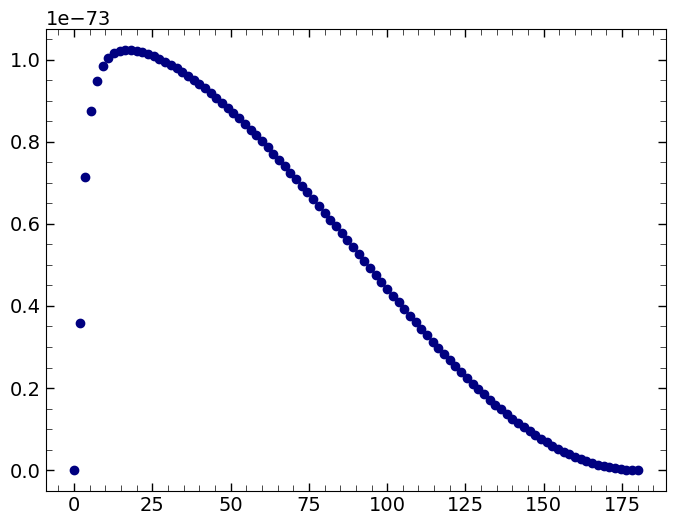

In [27]:
theta = np.linspace(0, np.pi, 100)
E_grb = 1
phi_ej = 0
beta = 0.999
plt.figure(figsize=(8, 6))
for theta in theta:
    h_in = u_grb.memory_initial_acceleration_GRB(E_grb, theta, phi_ej, 1e6, beta)
    plt.scatter(np.rad2deg(theta), h_in, color='navy')
plt.show()

### Influence of the afterglow compared to LISA sensitivity curve

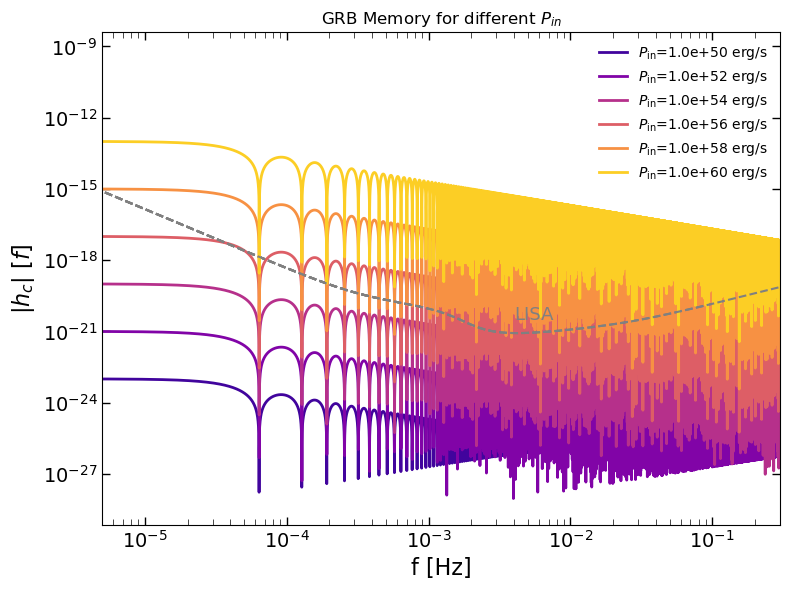

In [10]:
E_grb = 1e48
d_pc = 1e6
duration = 10
Pin_values = [1e50, 1e52, 1e54, 1e56, 1e58, 1e60]  # erg/s
theta_ej = np.deg2rad(10) # viewing angle
theta_j = np.deg2rad(90) # jet opening angle
phi_ej = 0.0
beta = 0.99

plt.figure(figsize=(8, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(Pin_values)))
for Pin_i, c in zip(Pin_values, colors):
    h_in = u_grb.memory_initial_acceleration_GRB(E_grb, theta_ej, phi_ej, d_pc, beta)
    h_aft = u_grb.memory_afterglow_injection(Pin_i, duration, theta_ej, theta_j, d_pc, beta)

    t_grb = np.logspace(-5.0, 5, 100000)
    t_grb, h_tot = u_grb.memory_total_waveform(t_grb, h_in, h_aft, duration, theta_ej, d_pc)

    f_grb, fft_grb_aft = u_grb.total_waveform_fft(h_in, h_aft, duration, theta_ej, d_pc)
    hc_grb = 2.0 * f_grb * np.abs(fft_grb_aft)

    plt.loglog(f_grb, hc_grb, color=c, lw=2.0, label=f"$P_{{\\rm in}}$={Pin_i:.1e} erg/s")
    plt.loglog(f_grb, np.sqrt(f_grb * lisa.Sn(f_grb)), color='grey', lw=1.5, ls='--')
plt.text(4e-3, 3e-21, 'LISA', color='grey', fontsize=13)
plt.xlabel("f [Hz]")
plt.ylabel(r"|$h_c|~[f]$")
plt.title("GRB Memory for different $P_{in}$")
plt.xlim(5e-6, 3e-1)

plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

/home/stu_brabant/Memory_effect/All_memory/LISA.py:104: RuntimeWarning: overflow encountered in exp
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))
/home/stu_brabant/Memory_effect/All_memory/LISA.py:104: RuntimeWarning: invalid value encountered in multiply
  Sc *= np.exp(-f**alpha + beta*f*np.sin(kappa*f))


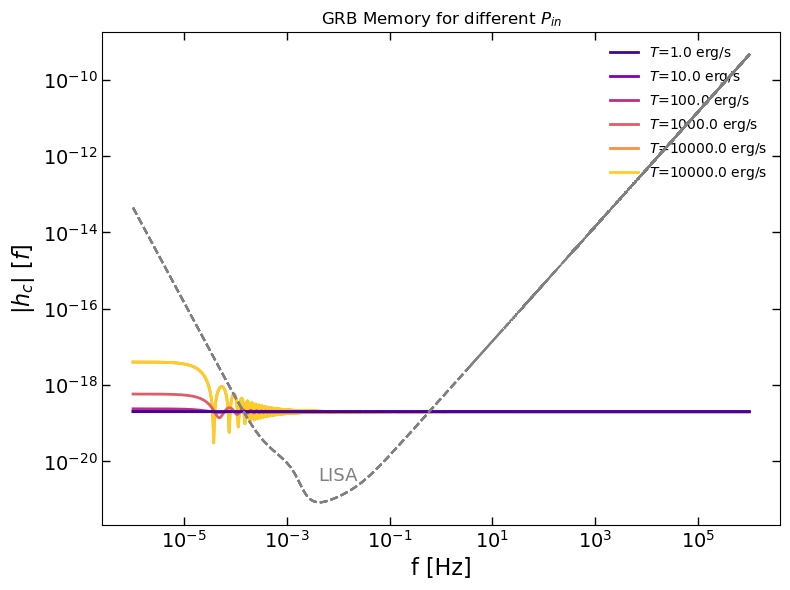

In [10]:
E_grb = 1e55
d_pc = 1e6
duration_v = [1, 10, 100, 1000, 10000, 10000]  # s
Pin_values = 1e55
theta_ej = np.deg2rad(10)
theta_j = np.deg2rad(5)
phi_ej = 0.0
beta = 0.99

plt.figure(figsize=(8, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(duration_v)))
for duration, c in zip(duration_v, colors):
    h_in = u_grb.memory_initial_acceleration_GRB(E_grb, theta_ej, phi_ej, d_pc, beta)
    h_aft = u_grb.memory_afterglow_injection(Pin_values, duration, theta_ej, theta_j, d_pc, beta)

    t_grb = np.logspace(-5.0, 5, 100000)
    t_grb, h_tot = u_grb.memory_total_waveform(t_grb, h_in, h_aft, duration, theta_ej, d_pc)

    f_grb, fft_grb_aft = u_grb.total_waveform_fft(h_in, h_aft, duration, theta_ej, d_pc)
    hc_grb = 2.0 * f_grb * np.abs(fft_grb_aft)

    plt.loglog(f_grb, hc_grb, color=c, lw=2.0, label=rf"$T$={duration:.1f} erg/s", zorder = 10-duration_v.index(duration))
    plt.loglog(f_grb, np.sqrt(f_grb * lisa.Sn(f_grb)), color='grey', lw=1.5, ls='--', zorder = 1000)
plt.text(4e-3, 3e-21, 'LISA', color='grey', fontsize=13, zorder = 1000)
plt.xlabel("f [Hz]")
plt.ylabel(r"|$h_c|~[f]$")
plt.title("GRB Memory for different $P_{in}$")


plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

## SNR heatmap for different pairs of values

In [5]:
# Let's vary the E_grb/ P_in vs distance (z and not Mpc) in SNR heatmap for LISA only for the GRB memory

def compute_hc_grb_only(params_grb):
    h_in = u_grb.memory_initial_acceleration_GRB(params_grb['E_grb'], params_grb['theta'], params_grb['phi_ej'], params_grb['r'], params_grb['beta'])
    h_aft = u_grb.memory_afterglow(params_grb['E_aft'], params_grb['theta'], params_grb['phi_ej'], params_grb['r'], params_grb['beta'])
    f_grb, fft_grb_aft = u_grb.total_waveform_fft(h_in, h_aft, params_grb['end_grb'], params_grb['theta'], params_grb['r'], radius=0)
    hc_grb = 2.0 * f_grb * np.abs(fft_grb_aft)
    # keep only the frequencies > 1e-4 Hz and < 1e-1 Hz
    mask = (f_grb >= 1e-4) & (f_grb <= 1e-1)
    f_grb = f_grb[mask]
    hc_grb = hc_grb[mask]
    return f_grb, hc_grb


SNR for GRB memory with LISA: 0.00876


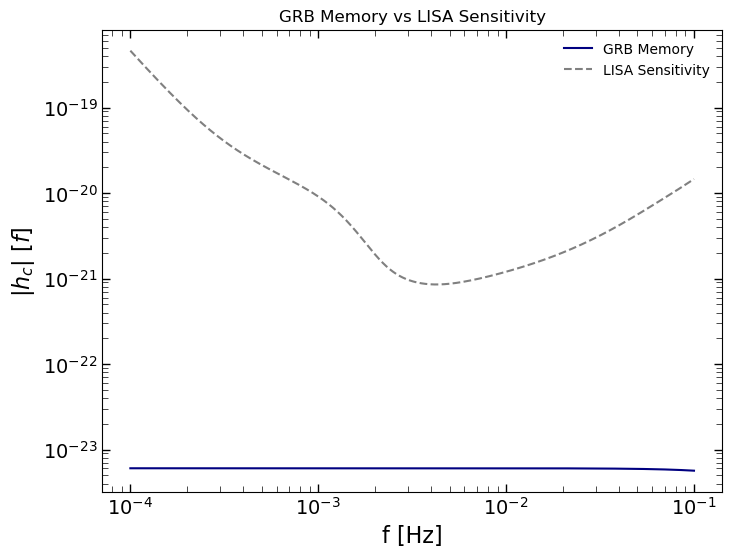

In [9]:
params_grb = {
    'E_grb': 1e52,
    'theta': np.deg2rad(10),
    'phi_ej': 0.0,
    'r': 50e6,  # pc 
    'E_aft': 1e52, # just for the test, we can assume that the energy of the afterglow is the same as the initial energy of the grb
    'beta': 0.99,
    'end_grb': 2, # s
}
f_grb, hc_grb = compute_hc_grb_only(params_grb)

# calcul snr for LISA
f_noise = f_grb
h_n = np.sqrt(f_noise * lisa.Sn(f_noise))
snr_grb = compute_snr(f_grb, hc_grb, f_noise, h_n)
plt.figure(figsize=(8, 6))
plt.loglog(f_grb, hc_grb, label='GRB Memory', color='navy')
plt.loglog(f_grb, np.sqrt(f_grb * lisa.Sn(f_grb)), label='LISA Sensitivity', color='grey', lw=1.5, ls='--')
plt.xlabel("f [Hz]")
plt.ylabel(r"|$h_c|~[f]$")
plt.title("GRB Memory vs LISA Sensitivity")
plt.legend(loc='upper right', frameon=False, fontsize=10)
print(f"SNR for GRB memory with LISA: {snr_grb:.5f}")
    

SNR min/max = 6.132129362162582e-08 6593.34435050699


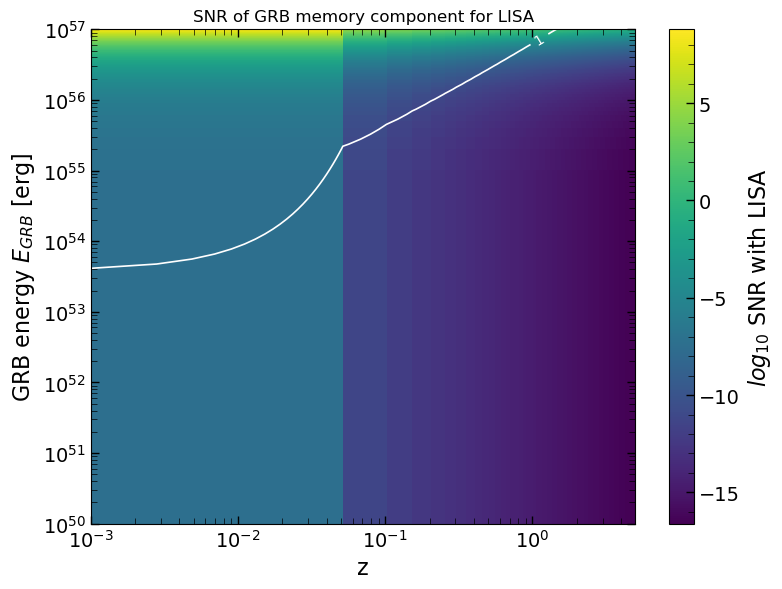

In [ ]:
from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
import numpy as np

E_grb_values = np.logspace(50, 57, 100)

z_values = np.linspace(1e-3, 5, 100)  
snr_grid_lisa = np.zeros((len(E_grb_values), len(z_values)))
for i, E_grb in enumerate(E_grb_values):
    for j, z in enumerate(z_values):
        # reconvert in pc for the compute_hc_grb_only function
        d_pc = Planck18.luminosity_distance(z).value * 1e6 # convert from Mpc to pc
        params_grb = {
            "E_grb": E_grb,
            "theta": np.deg2rad(10),
            "phi_ej": 0.0,
            "r": d_pc,
            "beta": 0.99,
            "end_grb": 10,
            "P_in": 0.5 * E_grb,
            "theta_j": np.deg2rad(5)
        }
        f_grb, hc_grb = compute_hc_grb_only(params_grb)
        
        snr_grid_lisa[i, j] = compute_snr(f_grb, hc_grb, f_grb, np.sqrt(f_grb * np.abs(lisa.Sn(f_grb))))

print("SNR min/max =", np.nanmin(snr_grid_lisa), np.nanmax(snr_grid_lisa))

Z, E = np.meshgrid(z_values, E_grb_values)

plt.figure(figsize=(8, 6))
im = plt.imshow(
    np.log(snr_grid_lisa),
    extent=(z_values[0], z_values[-1], E_grb_values[0], E_grb_values[-1]),
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='nearest'
)
plt.colorbar(im, label=r"$log_{10}$ SNR with LISA")
plt.xlabel("z")
plt.ylabel(r"GRB energy $E_{GRB}$ [erg]")
plt.xscale("log")
plt.yscale("log")


levels = [1, 10, 100]
contours = plt.contour(
    z_values, E_grb_values, np.log(snr_grid_lisa), levels=levels, colors='white', linewidths=1.2
)
plt.clabel(contours, inline=True, fontsize=10, fmt='%d')
plt.title("SNR of GRB memory component for LISA")
plt.tight_layout()
plt.show()

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
import utils_GRB_afterglow_phenom as u_grb
from matplotlib.colors import LogNorm
def plot_heatmap_snr(
    param_dict,
    xscale="log",
    yscale="log",
    levels=(1, 10, 100)
):

    scan_keys = [k for k, v in param_dict.items() if isinstance(v, (list, np.ndarray))]
    if len(scan_keys) != 2:
        raise ValueError("The dictionary must contain exactly 2 keys with lists for the scan axes")
    if "redshift" in scan_keys and "r" in scan_keys:
        raise ValueError("The dictionary cannot contain both 'redshift' and 'r' as scan keys, as they both represent distance. Please choose one of them for the scan and set the other as a fixed parameter.")
    x_key, y_key = scan_keys
    x_values = np.array(param_dict[x_key])
    y_values = np.array(param_dict[y_key])
    
    # Transform d in redshift if "redshift" is in the param_dict, otherwise keep the distance in pc
    if "redshift" in param_dict:
        z_values = np.array(param_dict["redshift"])
        d_values_pc = Planck18.luminosity_distance(z_values).value# convert from Mpc to pc
        param_dict["r"] = d_values_pc

    # Default parameters, overridden by param_dict
    param_grb = {
        "E_grb": 1e50,
        "theta": np.deg2rad(10),
        "phi_ej": 0.0,
        "r": 100e6,
        "beta": 0.99,
        "end_grb": 10,
        "P_in": 1e50,
        "theta_j": np.deg2rad(5)
    }
    
        

    param_grb.update({k: v for k, v in param_dict.items() if not isinstance(v, (list, np.ndarray))})

    snr_grid = np.zeros((len(y_values), len(x_values)))
    for i, y in enumerate(y_values):
        for j, x in enumerate(x_values):
            params = param_grb.copy()
            params[x_key] = x
            params[y_key] = y
            try:
                f, hc = compute_hc_grb_only(params)
                snr = compute_snr(f, hc, f, np.sqrt(f * np.abs(lisa.Sn(f))))
                snr_grid[i, j] = snr
            except Exception as e:
                print(e)
                snr_grid[i, j] = np.nan

    # Plot
    # if r is given for x or y, convert it to Mpc for the plot
    if x_key == "r":
        x_values = x_values / 1e6
        x_key = "Distance [Mpc]"
    if y_key == "r":
        y_values = y_values / 1e6
        y_key = "Distance [Mpc]"


    plt.figure(figsize=(8, 6))
    im = plt.imshow(
    snr_grid,
    extent=(x_values[0], x_values[-1], y_values[0], y_values[-1]),
    aspect='auto',
    interpolation='gaussian',
    origin='lower',
    cmap='plasma',
    norm=LogNorm(vmin=np.nanmin(snr_grid[snr_grid>1e-2]), vmax=np.nanmax(snr_grid))
)
    
    plt.colorbar(im, label="SNR with LISA")
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.xscale(xscale)
    plt.yscale(yscale)

    contours = plt.contour(
        x_values, y_values, snr_grid, levels=levels, colors='white', linewidths=1.2, linestyles='--'
    )
    plt.clabel(contours, inline=True, fontsize=10, fmt='%d')
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18, z_at_value
import astropy.units as u


def plot_snr_evolution(
    param_dict,
    xscale="log",
    yscale="log"
):
    """
    Trace l'évolution du SNR en fonction d'un seul paramètre variable.

    Parameters
    ----------
    param_dict : dict
        Dictionnaire contenant exactement une clé avec une liste de valeurs pour le paramètre à scanner.
        Les autres clés doivent être des valeurs uniques pour les paramètres fixes.
    xscale : str, optional
        Échelle pour l'axe des x (par défaut "log").
    yscale : str, optional
        Échelle pour l'axe des y (par défaut "log").
    """
    # Identifier le paramètre à scanner
    scan_keys = [k for k, v in param_dict.items() if isinstance(v, (list, np.ndarray))]
    if len(scan_keys) != 1:
        raise ValueError("Le dictionnaire doit contenir exactement 1 clé avec une liste de valeurs pour le scan.")
    
    scan_key = scan_keys[0]
    scan_values = np.array(param_dict[scan_key])

    # Paramètres par défaut, qui seront écrasés par ceux fournis dans param_dict
    param_grb = {
        "E_grb": 1e50, "theta": np.deg2rad(10), "phi_ej": 0.0,
        "r": 100e6,  
        "beta": 0.99, "end_grb": 10, "P_in": 1e50, "theta_j": np.deg2rad(5)
    }
    param_grb_units = {
        "E_grb": "erg", "theta": "rad", "phi_ej": "rad", "r": "Mpc",
        "beta": "c", "end_grb": "s", "P_in": "erg/s", "theta_j": "rad", "redshift": ""
    }
    
    # Mettre à jour les paramètres fixes (ceux qui ne sont pas des listes)
    param_grb.update({k: v for k, v in param_dict.items() if not isinstance(v, (list, np.ndarray))})

    snr_results = []

    # Boucle sur le paramètre à scanner
    for value in scan_values:
        params_loop = param_grb.copy()
        params_loop[scan_key] = value
        
        # Gérer la conversion d'unité pour la distance juste avant l'appel
        # La fonction compute_hc_grb_only attend 'r' en parsecs (pc).
        if 'r' in params_loop:
            # On convertit la distance de Mpc en pc
            params_loop['r'] = params_loop['r'] * 1e6
        elif 'redshift' in params_loop:
            # Si on scanne le redshift, on le convertit en distance (pc)
            z = params_loop.pop('redshift')
            # .value donne la distance en Mpc, on convertit en pc
            params_loop['r'] = Planck18.luminosity_distance(z).value * 1e6

        try:
            f, hc = compute_hc_grb_only(params_loop)
            snr = compute_snr(f, hc, f, np.sqrt(f * np.abs(lisa.Sn(f))))
            snr_results.append(snr)
        except Exception as e:
            print(f"Erreur pour {scan_key}={value}: {e}")
            snr_results.append(np.nan)

    # Création du graphique
    plt.figure(figsize=(10, 6))
    plt.plot(scan_values, snr_results, marker='o', linestyle='--', label=f'SNR vs {scan_key}')
    
    plt.xlabel(f"{scan_key} [{param_grb_units.get(scan_key, '')}]")
    plt.ylabel("Signal-to-Noise Ratio (SNR) with LISA")
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.title(f"Évolution du SNR en fonction de {scan_key}")
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

